The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
    ▶ Running new sim

[H%] t=  412.0016 hr  total_H=9.937620e-01
  layer | trapped%    mobile%     total%   |  within-layer: mobile% trapped%
    A   | 9.961e+01 1.064e-11 9.961e+01 |   0.000 100.000
    B   | 7.332e-05 2.210e-11 7.332e-05 |   0.000 100.000
    C   | 3.853e-01 3.046e-11 3.853e-01 |   0.000 100.000
    D   | 6.420e-08 4.493e-11 6.425e-08 |   0.070  99.930
    E   | 1.776e-06 1.245e-09 1.777e-06 |   0.070  99.930

[H%] t=  481.5751 hr  total_H=9.937536e-01
  layer | trapped%    mobile%     total%   |  within-layer: mobile% trapped%
    A   | 9.962e+01 1.058e-11 9.962e+01 |   0.000 100.000
    B   | 7.292e-05 2.198e-11 7.292e-05 |   0.000 100.000
    C   | 3.843e-01 3.038e-11 3.843e-01 |   0.000 100.000
    D   | 6.280e-08 4.394e-11 6.284e-08 |   0.070  99.930
    E   | 1.668e-06 1.169e-09 1.669e-06 |   0.070  99.930

[H%] t=  582.4516 hr  total_H=9.937373e-01
  layer | trapped%    mo

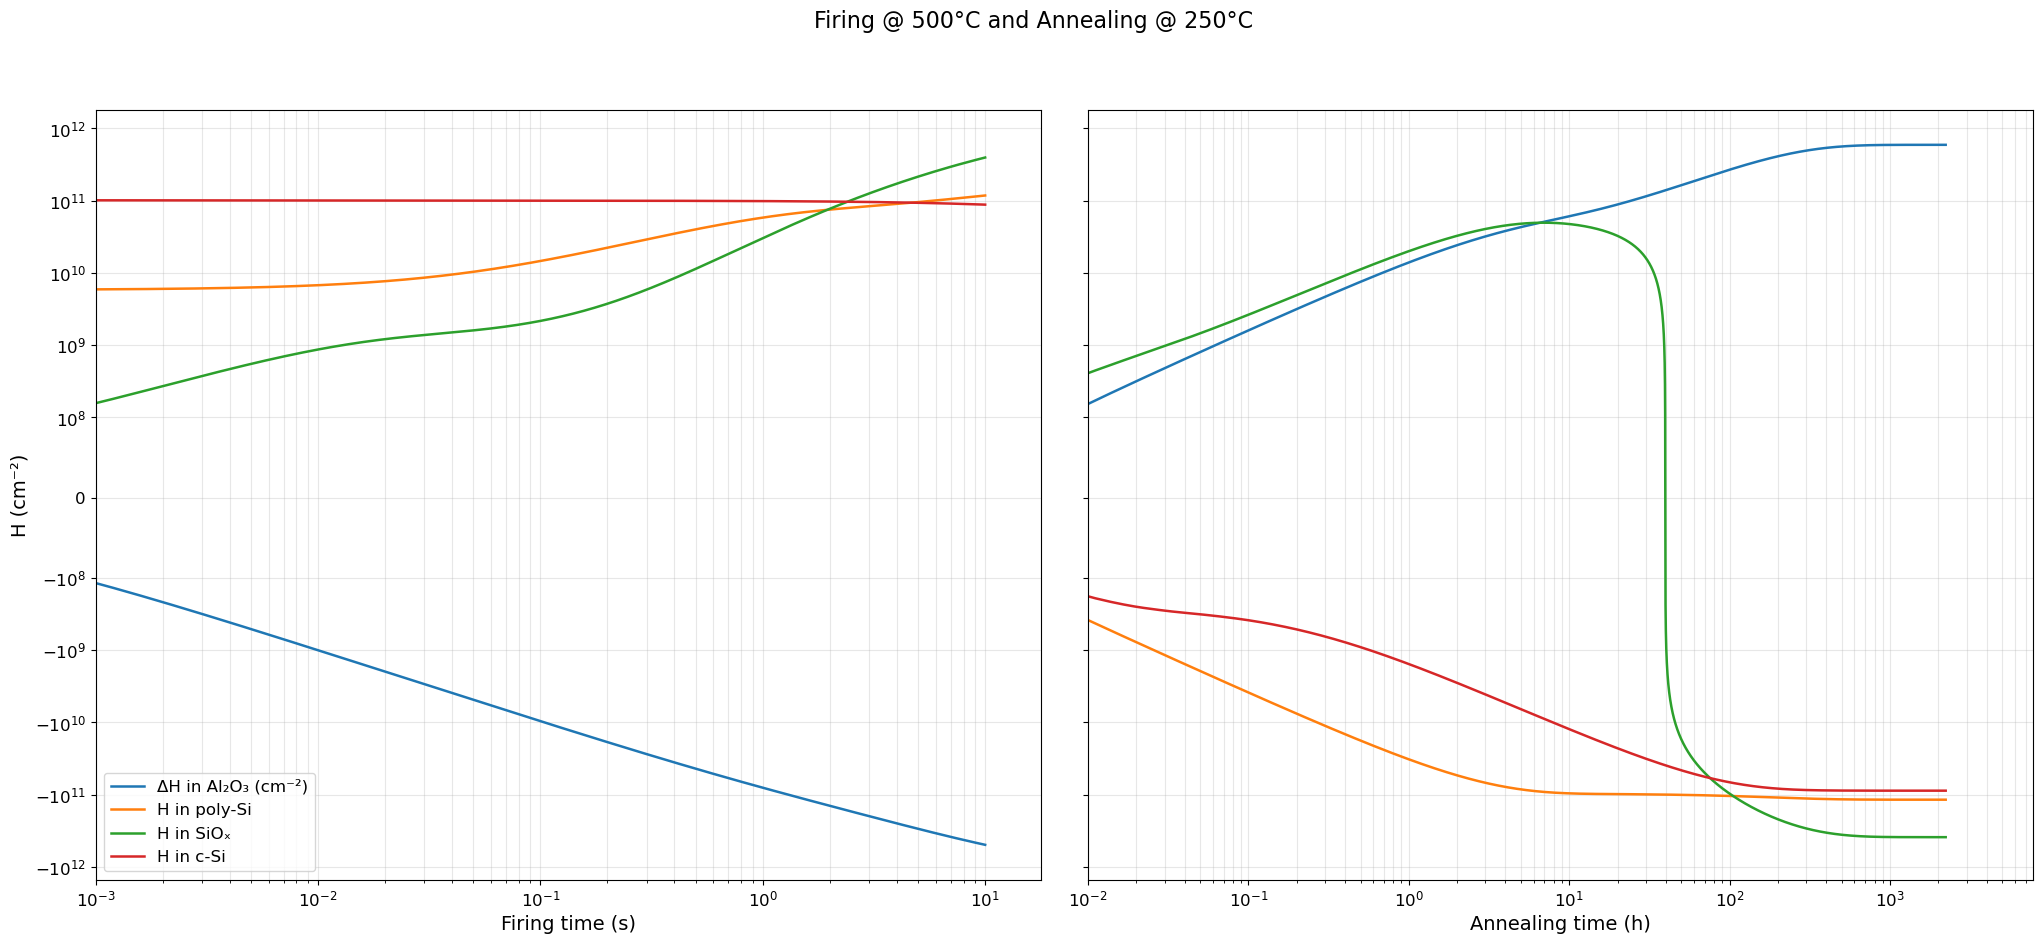

[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_firing.csv
[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_annealing.csv


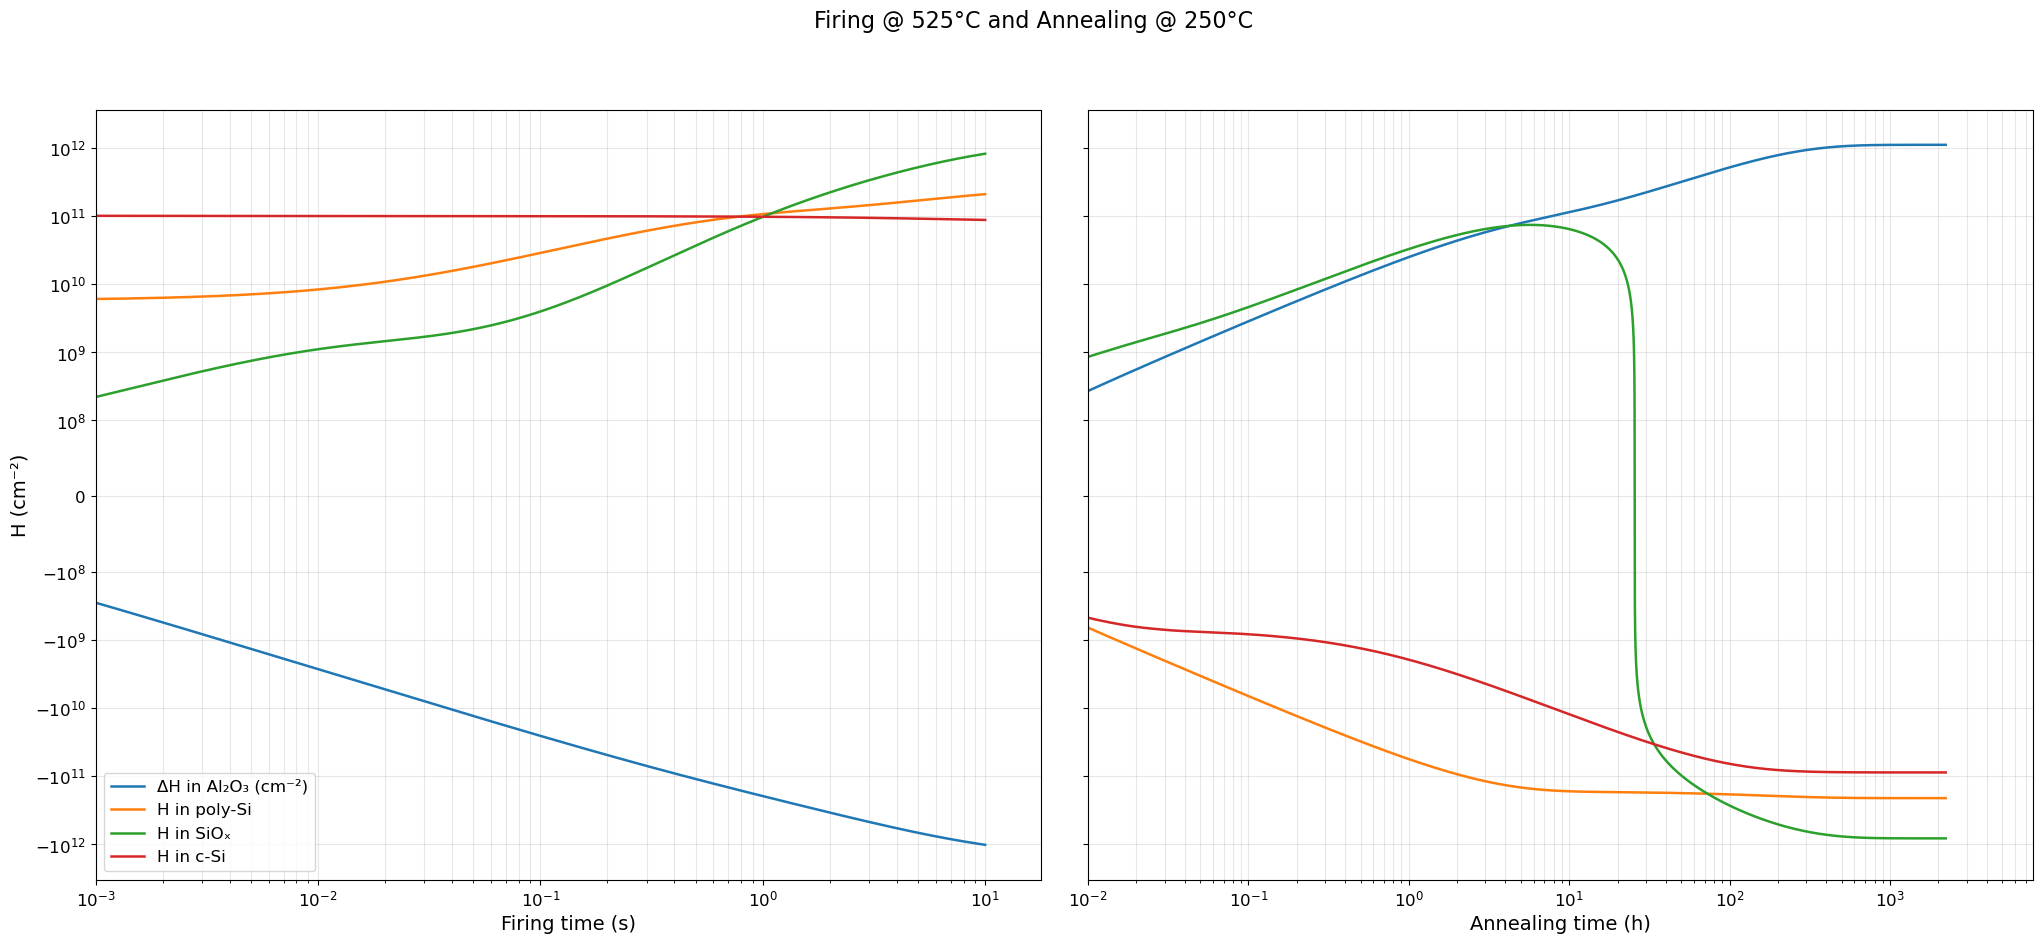

[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_firing.csv
[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_annealing.csv


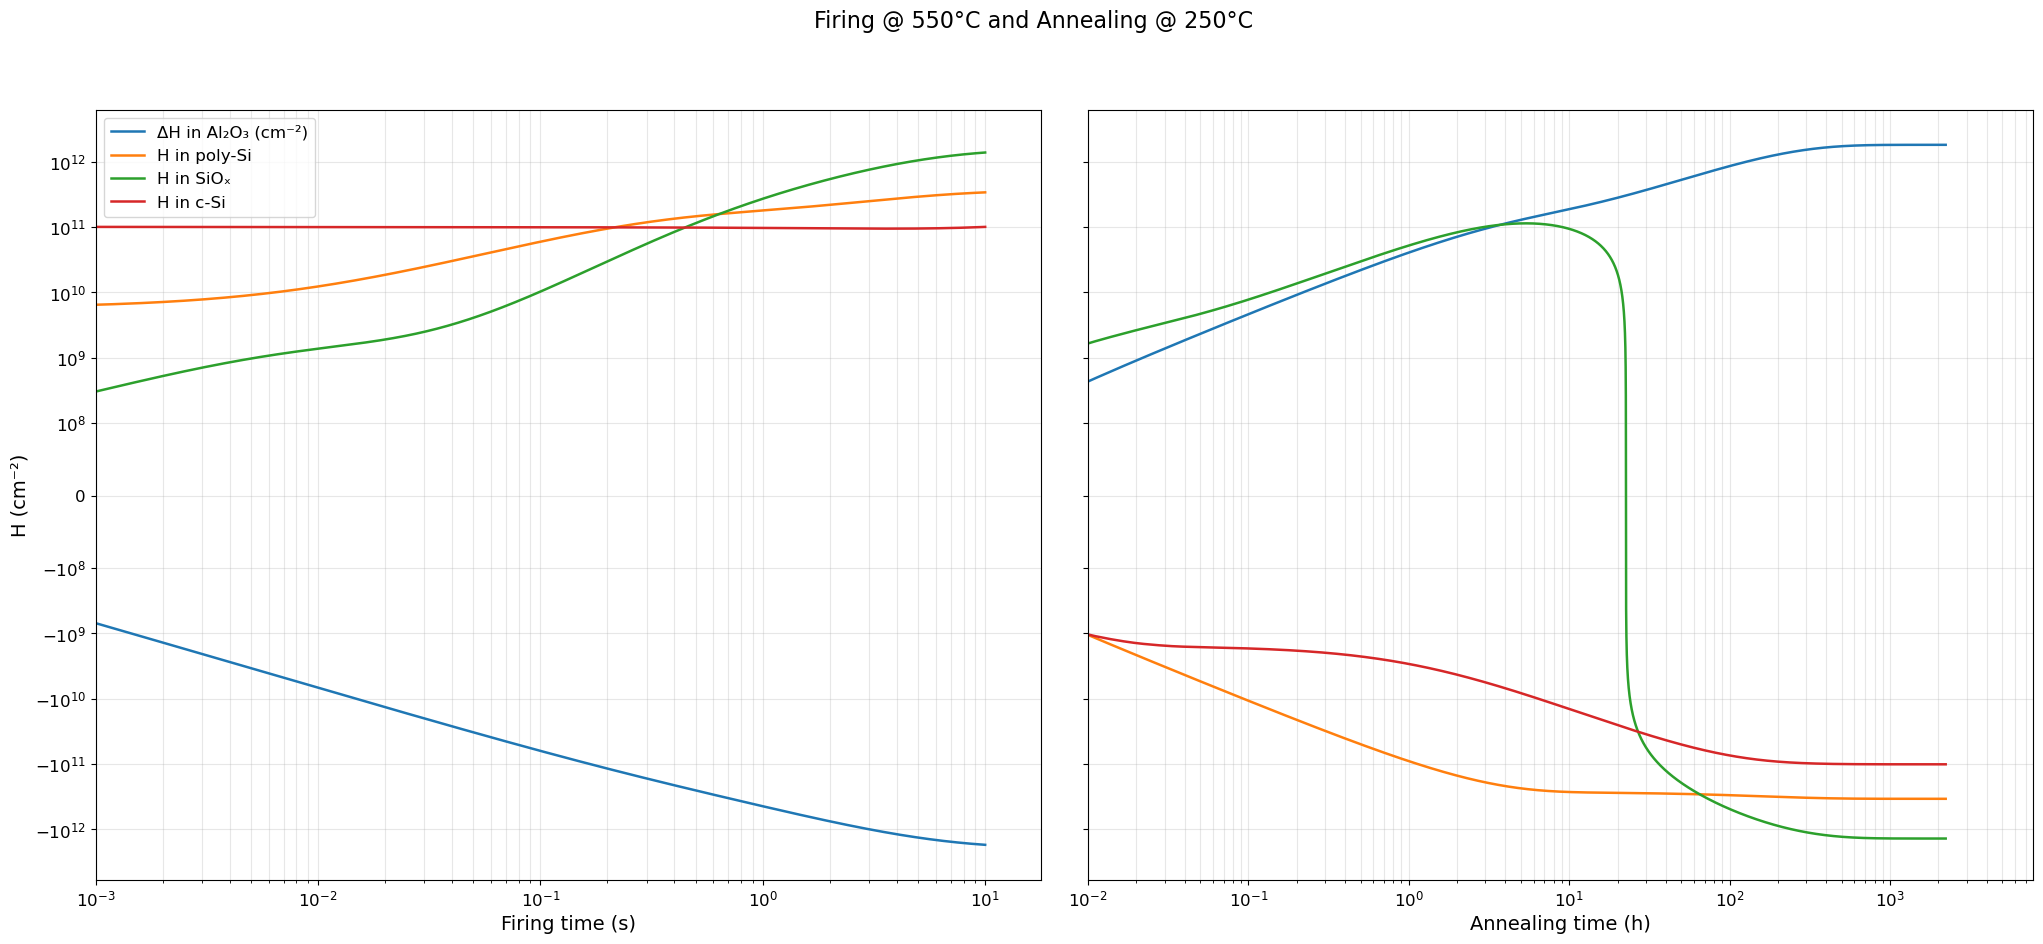

[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_firing.csv
[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_annealing.csv


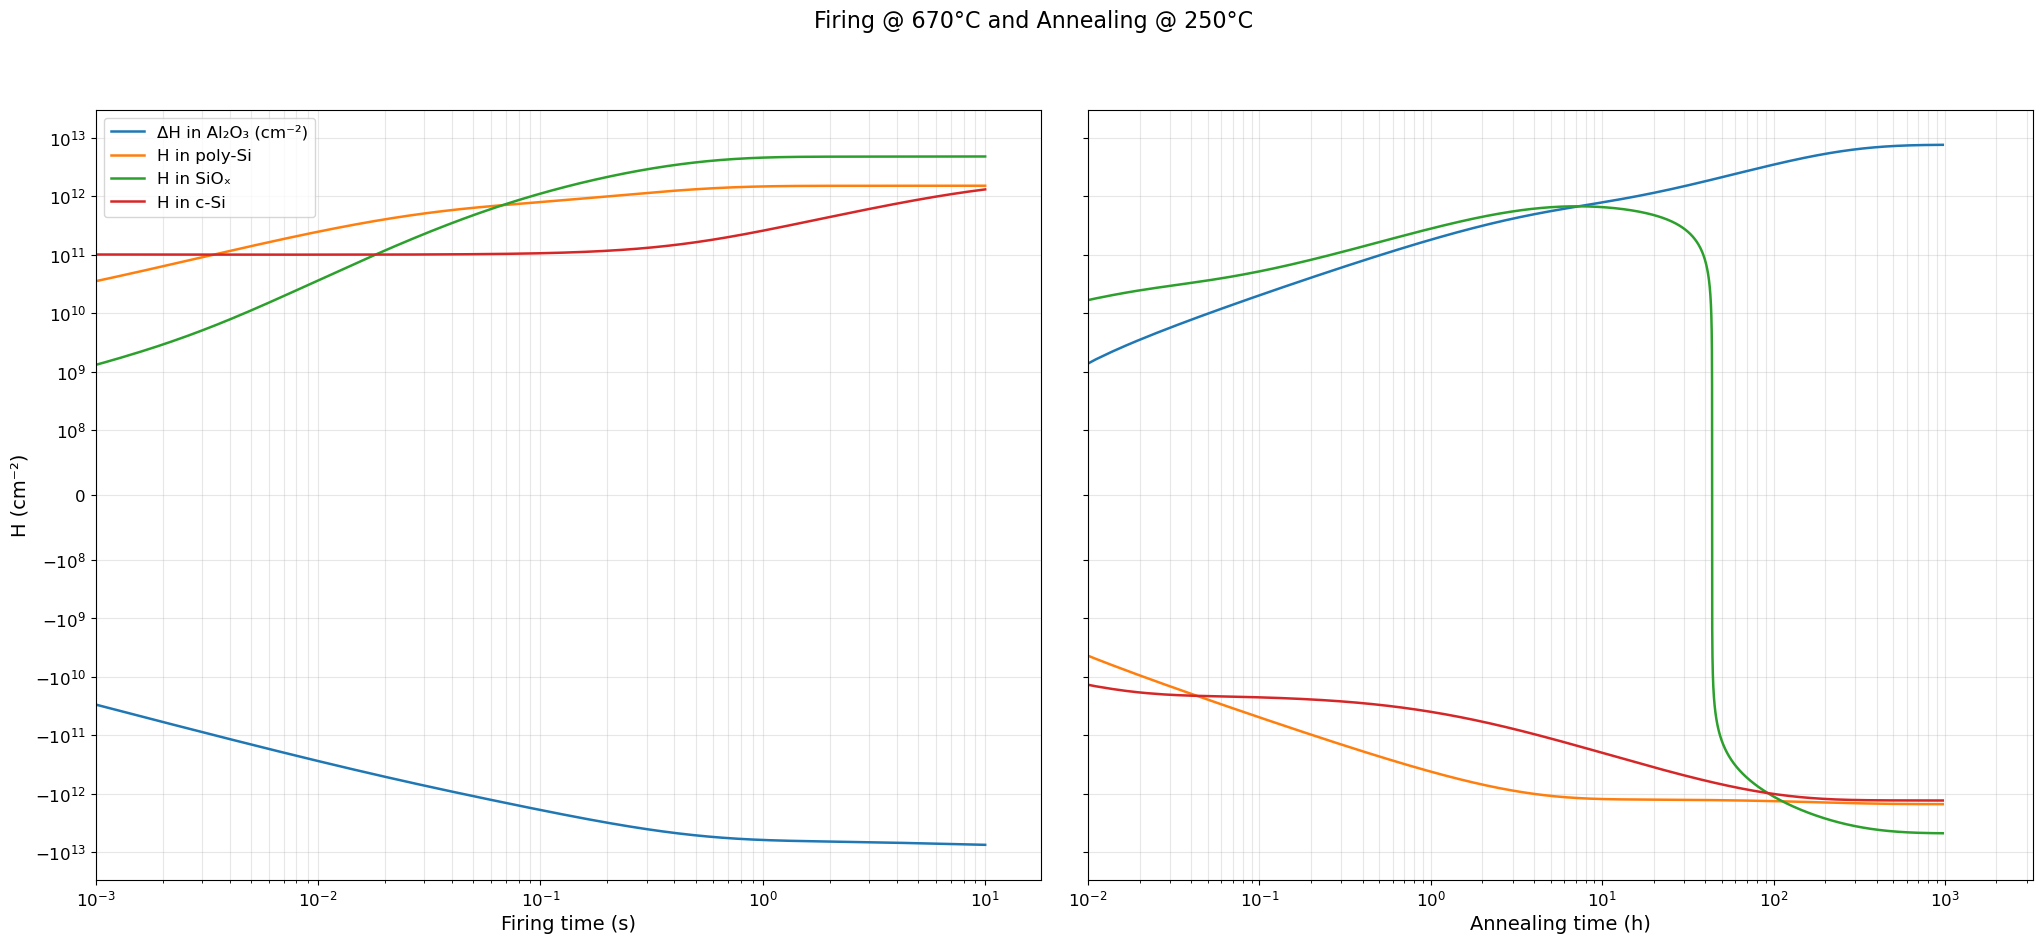

[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_firing.csv
[save_curves_for_origin] Saved 4 curves → ./origin_exports/H_dt_annealing.csv


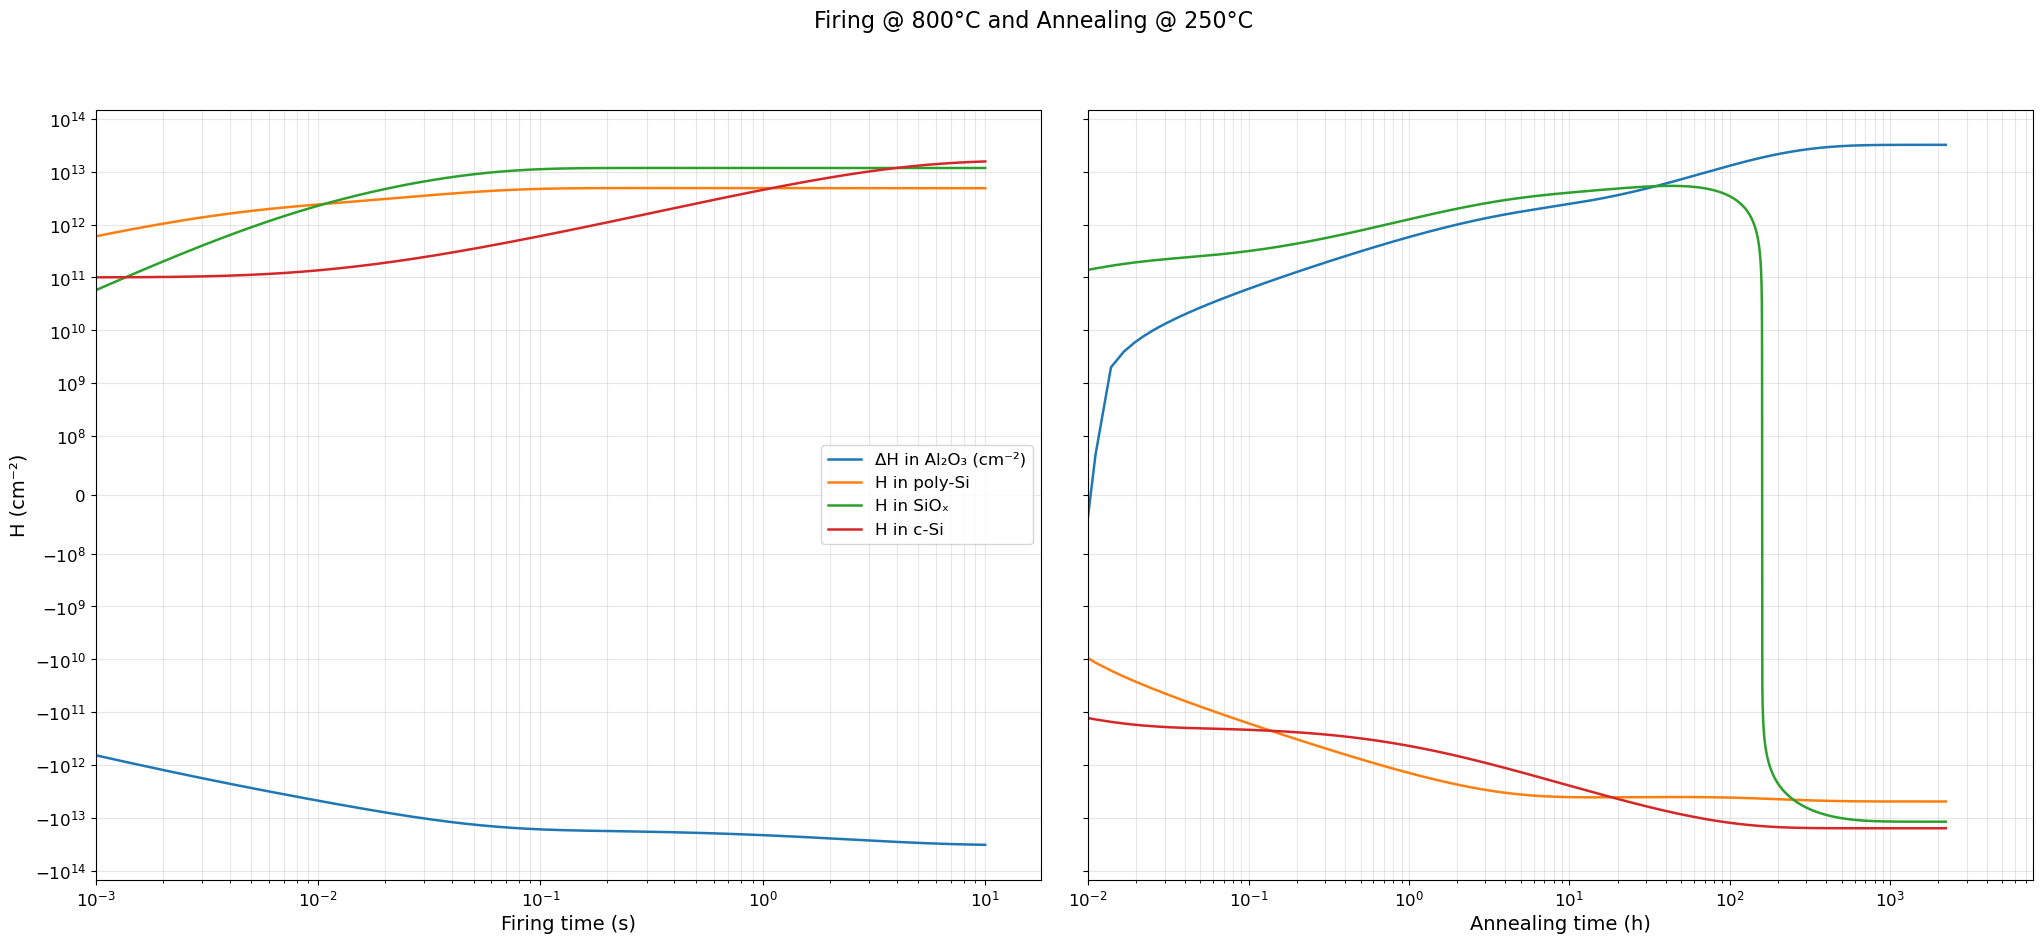

[save_curves_for_origin] Saved 8 curves → ./origin_exports/anneal_sweep.csv


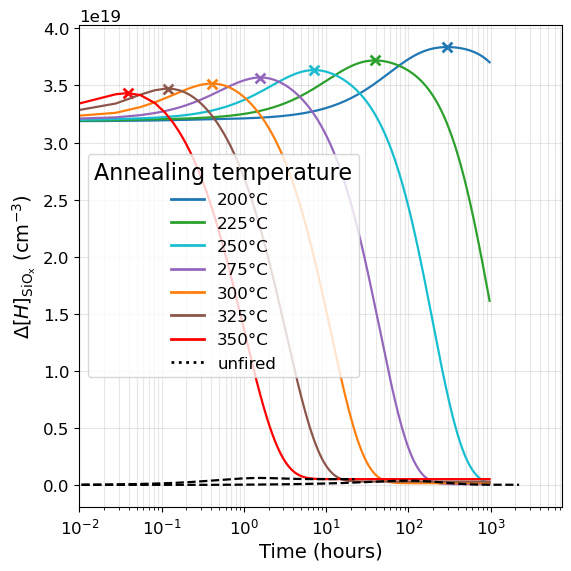

[save_curves_for_origin] Saved 10 curves → ./origin_exports/firing_siox.csv


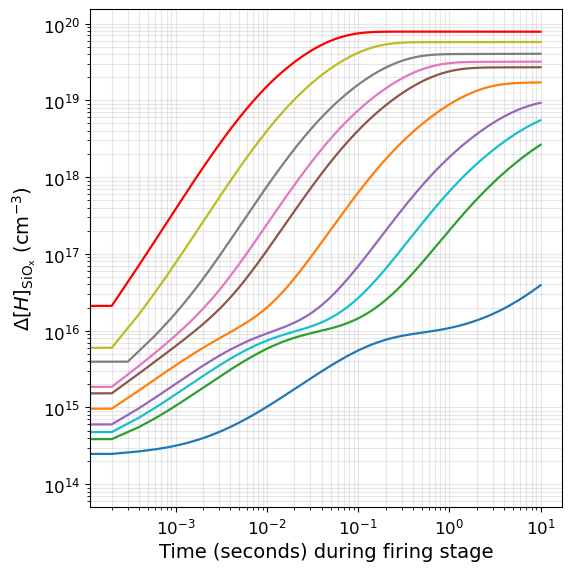

[save_curves_for_origin] Saved 10 curves → ./origin_exports/fire_sweep.csv


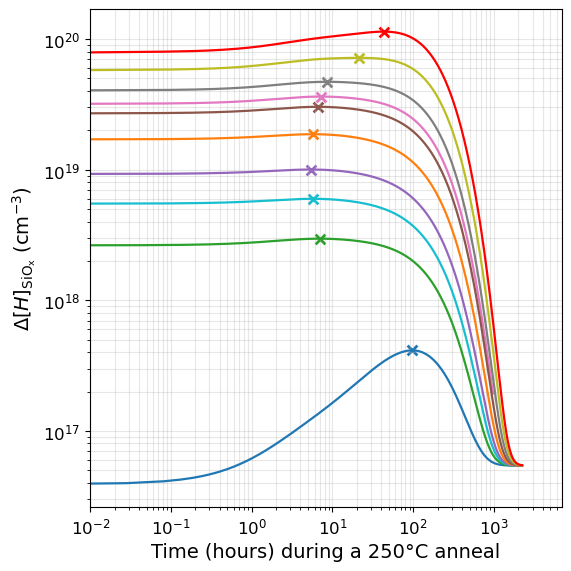

[save_curves_for_origin] Saved 10 curves → ./origin_exports/fire2_sweep.csv


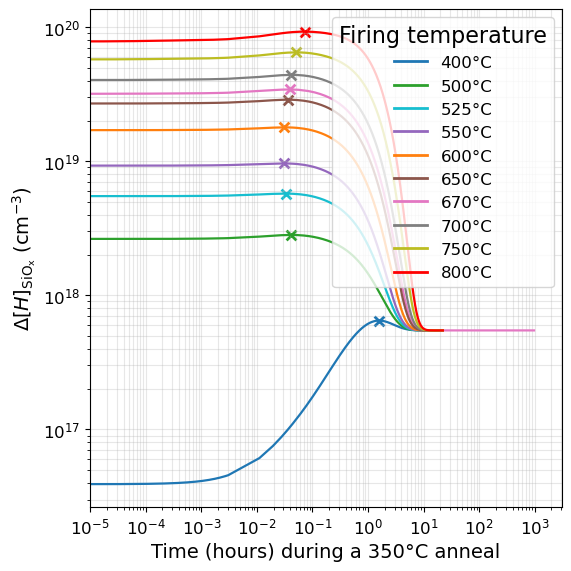

[[600, 650, 700, 750, 800], [6.066666666666666, 4.533333333333333, 11.583333333333334, 17.183333333333334, 89.03333333333333]]
[600, 650, 700, 750, 800] - [6.066666666666666, 4.533333333333333, 11.583333333333334, 17.183333333333334, 89.03333333333333]
[save_curves_for_origin] Saved 1 curves → ./origin_exports/FireT_vs_peak.csv


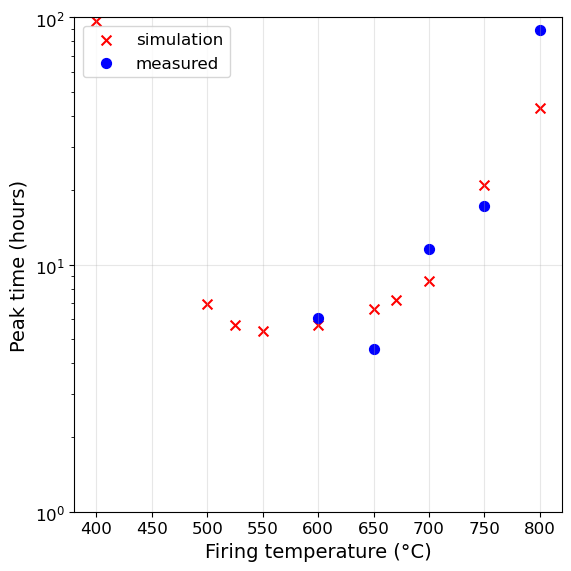

In [42]:
###
### THIS IS THE CELL I USE TO MAKE THE PAPER PLOTS, DO NOT CHANGE UNLESS YOU ARE MAKING PAPER PLOTS
###
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sweeps as swp
import simulation_manager as sm
import vizkit as viz
import numpy as np
# import helpers as h

# ---- param sets to sweep ----
good_params = [
###
### THIS IS THE CELL I USE TO MAKE THE PAPER PLOTS, DO NOT CHANGE UNLESS YOU ARE MAKING PAPER PLOTS
###
    #paper params
    {'A_detrap': 2.5, 'A_trap': 0.9,
     'B_detrap': 1.3,
     'C_detrap': 1.45,
     'D_detrap': 1.2,
     'A_trap_attemptfreq': 1e+13,
     'B_trap_attemptfreq': 1e+13,
     'C_trap_attemptfreq': 1e+13, 
     'D_trap_attemptfreq': 5e+12,
     'A_detrap_attemptfreq': 1e+12,
     'B_detrap_attemptfreq': 1e+12,
     'C_detrap_attemptfreq': 1e+12, 
     'D_detrap_attemptfreq': 1e+12},
    
#     {'A_detrap': 2.5, 'A_trap': 0.9,
#     'B_detrap': 0.9,
#     'C_detrap': 1.45,
#     'D_detrap': 1.1,
#     'A_trap_attemptfreq': 1e+13,
#     'B_trap_attemptfreq': 1e+13,
#     'C_trap_attemptfreq': 1e+13, 
#     'D_trap_attemptfreq': 5e+12,
#     'A_detrap_attemptfreq': 1e+12,
#     'B_detrap_attemptfreq': 1e+12,
#     'C_detrap_attemptfreq': 1e+12, 
#     'D_detrap_attemptfreq': 1e+12},

]

###
### THIS IS THE CELL I USE TO MAKE THE PAPER PLOTS, DO NOT CHANGE UNLESS YOU ARE MAKING PAPER PLOTS
###
# ---- sweep settings (explicit °C + seconds) ----
anneal_temps_C      = [200,225,250,275,300,325,350]#300,350]
annealing_fire_C    = 670
annealing_fire_s    = 10
annealing_sweep_s   = 3_500_000

firing_temps_C      = [400,500,525,550,600,650, 700, 750,800,]
firing_anneal_C     = 250         
firing_anneal_s     = 8000000
firing2_anneal_C    = 350  
firing2_anneal_s    = 80000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

# results_dir         = "./sim_data_sweeps"   # change to None if you prefer default; plots aren’t saved
petsc_options       = None
verbose             = False

j = 1
for base_params in good_params:

    schedules = []

    # --- 1) Annealing sweep: fixed firing, variable anneal
    sched, stage = swp.make_annealing_sweep(
        anneal_temps=anneal_temps_C,
        fire_temp=annealing_fire_C,
        fire_s=annealing_fire_s,
        anneal_s=annealing_sweep_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    schedules+=sched
    # --- 2) Firing sweep: fixed anneal, variable firing
    sched, stage = swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    
    schedules+=sched
    
    
    # schedules = swp.make_fancy_firing()
    
    sched, stage = swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing2_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing2_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    
    schedules+=sched
    unfired_T=400
    
    sched, stage = swp.make_unfired_sweep(anneal_temp=250,fire_temp=unfired_T,fire_s=annealing_fire_s,anneal_s=annealing_sweep_s)
    schedules+=sched
    
    mgr = sm.SimulationManager(base_params=base_params,temp_schedules=schedules, stage_names=stage)#"firing2_1","firing2_2","firing2_3"])

    # print(schedules)
    # matches = mgr.results_with_stage_temperature(stage="firing", target_T=670)

###
### THIS IS THE CELL I USE TO MAKE THE PAPER PLOTS, DO NOT CHANGE UNLESS YOU ARE MAKING PAPER PLOTS
###
    PANELS = ['anneal_sweep','firing_siox_log','fire_sweep_log','fire2_sweep_log','peak_firingT']#,'exp_overlay']
    PANEL_CTX = [annealing_fire_C, firing_anneal_C, firing_anneal_C, firing2_anneal_C, firing_anneal_C]#, annealing_fire_C]

    #viz.plot_multistage_firing_sweep_panels(mgr, annealing_temp_C=250,ylog=True)

    
    # viz.plot_two_stage_flux_panels(mgr,firing_temp_C=670,annealing_temp_C=250,ylog=True,use_seconds=False,)
    
    viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=500, annealing_temp_C=250, ylog=True, )  # set False if you want hours on x for anneal
    viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=525, annealing_temp_C=250, ylog=True, ) 
    viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=550, annealing_temp_C=250, ylog=True, ) 
    viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=670, annealing_temp_C=250, ylog=True, ) 
    viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=800, annealing_temp_C=250, ylog=True, ) 
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=670, annealing_temp_C=250, ylog=True, ) 
    
    viz.plot_paper(mgr,PANELS,PANEL_CTX,unfired_T=unfired_T)
    
    #viz.plot_full_single_analysis(mgr,PANELS,PANEL_CTX,x_lim_left=1e-2)#'fire_sweep_log','peak_firingT','exp_overlay'],
    #                                #[firing_anneal_C,],#firing2_anneal_C,firing_anneal_C,annealing_fire_C],
    #                                 # )
    
   

   
    j += 1
    


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[cache miss] saved → /home/adam/code/diffusion_model/sim_data/sim_ca6d33b47905468b.npz
Sim1 final state (fraction units):
    A_mobile = 2.771143e-08
   A_trapped = 9.899251e-01
    B_mobile = 2.765270e-08
   B_trapped = 5.179998e-06
    C_mobile = 2.760901e-08
   C_trapped = 3.186887e-03
    D_mobile = 2.752036e-08
   D_trapped = 7.564620e-09
    E_mobile = 2.016721e-08
   E_trapped = 5.544550e-09
[cache miss] saved → /home/adam/code/diffusion_model/sim_data/sim_be1b3aea4949733a.npz
[cache miss] saved → /home/adam/code/diffusion_model/sim_data/sim_b943f3b522307af0.npz
[cache miss] saved → /home/adam/code/diffusion_model/sim_data/sim_9a3e8497b11fc914.npz
[cache miss] saved → /home/adam/code/diffusion_model/sim_data/sim_bb39111000fd21d9.npz


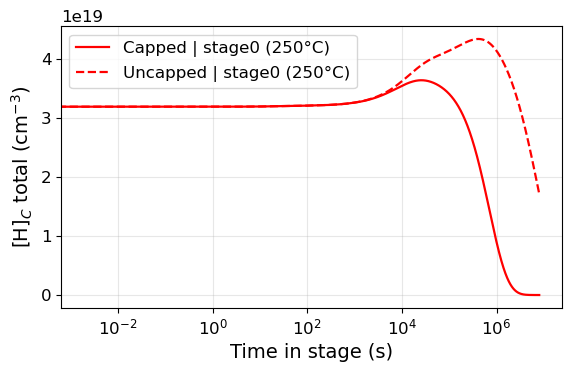

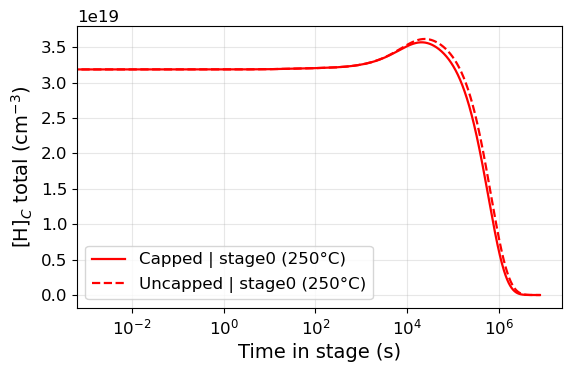

In [54]:
%load_ext autoreload
%autoreload 2

import numpy as np
import fourstates as fs
import vizkit as viz

# ----------------------------
# First run: your "paper" params
# ----------------------------
paper_params = [
    {
        "A_detrap": 2.5, "A_trap": 0.9,
        "B_detrap": 1.3,
        "C_detrap": 1.45,
        "D_detrap": 1.2,
        "A_trap_attemptfreq": 1e13,
        "B_trap_attemptfreq": 1e13,
        "C_trap_attemptfreq": 1e13,
        "D_trap_attemptfreq": 5e12,
        "A_detrap_attemptfreq": 1e12,
        "B_detrap_attemptfreq": 1e12,
        "C_detrap_attemptfreq": 1e12,
        "D_detrap_attemptfreq": 1e12,
    }
]


paper_overrides = paper_params[0]


schedule1 = "10:670C"  

p1 = fs.build_params(
    temp_schedule=schedule1,
    **paper_overrides,
)

res1 = fs.simulate(p1, verbose=True)
u_final = np.asarray(res1["ut"][-1], dtype=float).reshape(-1)  # length 10



# handy labeled view of the final state
final_by_name = {name: float(u_final[i]) for name, i in fs.UT_INDEX.items()}
print("Sim1 final state (fraction units):")
for k in sorted(final_by_name):
    print(f"  {k:>10s} = {final_by_name[k]:.6e}")

# ----------------------------
# Second run: start from sim1 final state
# (requires your simulate(..., u0=...) patch)
# ----------------------------
schedule2 = "8000000:250C"  

paper_overrides_2 = dict(paper_overrides)   # shallow copy
paper_overrides_2["A_detrap"] = 10
paper_overrides_2["A_trap"]   = 1.3
paper_overrides_2["N_A"] = 1


p2_capped = fs.build_params(
    temp_schedule=schedule2,
    **paper_overrides,   # use modified paper params for sim2
)

p2_uncapped = fs.build_params(
    temp_schedule=schedule2,
    **paper_overrides_2,   # use modified paper params for sim2
)


annealing_capped = fs.simulate(p2_capped, u0=u_final, verbose=True)
u_final[fs.state_index("A", "trapped")] = 1e-15
u_final[fs.state_index("A", "mobile")] = 1e-15
annealing_uncapped = fs.simulate(p2_uncapped, u0=u_final, verbose=True)


ax = viz.plot_siox_C_all_stages([annealing_capped,annealing_uncapped], labels=["Capped", "Uncapped"], kind="total", ylog=False)



#######
####3#

paper_overrides_2 = dict(paper_overrides)   # shallow copy
paper_overrides_2["A_detrap"] = 10
paper_overrides_2["A_trap"]   = 1.3
paper_overrides_2["N_A"] = 100


p2_capped = fs.build_params(
    temp_schedule=schedule2,
    **paper_overrides,   # use modified paper params for sim2
)

p2_uncapped = fs.build_params(
    temp_schedule=schedule2,
    **paper_overrides_2,   # use modified paper params for sim2
)


annealing_capped = fs.simulate(p2_capped, u0=u_final, verbose=True)
u_final[fs.state_index("A", "trapped")] = 1e-15
u_final[fs.state_index("A", "mobile")] = 1e-15
annealing_uncapped = fs.simulate(p2_uncapped, u0=u_final, verbose=True)


ax = viz.plot_siox_C_all_stages([annealing_capped,annealing_uncapped], labels=["Capped", "Uncapped"], kind="total", ylog=False)

# ax = viz.plot_siox_C_all_stages(annealing_uncapped, ax=ax,kind="total", ylog=False)

# print("\nDone. Sim2 started from Sim1 final state.")
# print("Sim2 final time [s] =", float(annealing_uncapped["times"][-1]))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[cache hit] /home/adam/code/diffusion_model/sim_data/sim_19be2ff4c428eacb.npz
Sim1 final state (fraction units):
    A_mobile = 2.771143e-08
   A_trapped = 9.899251e-01
    B_mobile = 2.765270e-08
   B_trapped = 5.179998e-06
    C_mobile = 2.760901e-08
   C_trapped = 3.186887e-03
    D_mobile = 2.752036e-08
   D_trapped = 7.564620e-09
    E_mobile = 2.016721e-08
   E_trapped = 5.544550e-09
[cache hit] /home/adam/code/diffusion_model/sim_data/sim_2ff446fd89952884.npz
[cache miss] saved → /home/adam/code/diffusion_model/sim_data/sim_2145fc43f03f8d35.npz


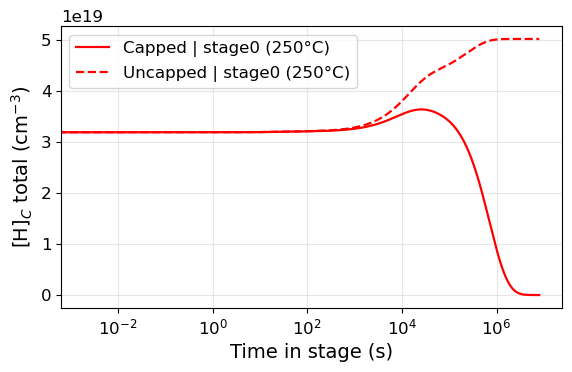

In [51]:
%load_ext autoreload
%autoreload 2

import numpy as np
import fourstates as fs
import vizkit as viz

# ----------------------------
# First run: your "paper" params
# ----------------------------
paper_params = [
    {
        "A_detrap": 2.5, "A_trap": 0.9,
        "B_detrap": 1.3,
        "C_detrap": 1.45,
        "D_detrap": 1.2,
        "A_trap_attemptfreq": 1e13,
        "B_trap_attemptfreq": 1e13,
        "C_trap_attemptfreq": 1e13,
        "D_trap_attemptfreq": 5e12,
        "A_detrap_attemptfreq": 1e12,
        "B_detrap_attemptfreq": 1e12,
        "C_detrap_attemptfreq": 1e12,
        "D_detrap_attemptfreq": 1e12,
    }
]


paper_overrides = paper_params[0]


schedule1 = "10:670C"  

p1 = fs.build_params(
    temp_schedule=schedule1,
    **paper_overrides,
)

res1 = fs.simulate(p1, verbose=True)
u_final = np.asarray(res1["ut"][-1], dtype=float).reshape(-1)  # length 10



# handy labeled view of the final state
final_by_name = {name: float(u_final[i]) for name, i in fs.UT_INDEX.items()}
print("Sim1 final state (fraction units):")
for k in sorted(final_by_name):
    print(f"  {k:>10s} = {final_by_name[k]:.6e}")

# ----------------------------
# Second run: start from sim1 final state
# (requires your simulate(..., u0=...) patch)
# ----------------------------
schedule2 = "8000000:250C"  

paper_overrides_2 = dict(paper_overrides)   # shallow copy
paper_overrides_2["A_detrap"] = 1.2
paper_overrides_2["A_trap"]   = 2
paper_overrides_2["N_B"]   = 1e-3


p2_capped = fs.build_params(
    temp_schedule=schedule2,
    **paper_overrides,   # use modified paper params for sim2
)

p2_uncapped = fs.build_params(
    temp_schedule=schedule2,
    **paper_overrides_2,   # use modified paper params for sim2
)


annealing_capped = fs.simulate(p2_capped, u0=u_final, verbose=True)
u_final[fs.state_index("A", "trapped")] = u_final[fs.state_index("B", "trapped")]
u_final[fs.state_index("A", "mobile")] = u_final[fs.state_index("B", "mobile")]
annealing_uncapped = fs.simulate(p2_uncapped, u0=u_final, verbose=True)


ax = viz.plot_siox_C_all_stages([annealing_capped,annealing_uncapped], labels=["Capped", "Uncapped"], kind="total", ylog=False)
# ax = viz.plot_siox_C_all_stages(annealing_uncapped, ax=ax,kind="total", ylog=False)

# print("\nDone. Sim2 started from Sim1 final state.")
# print("Sim2 final time [s] =", float(annealing_uncapped["times"][-1]))

In [52]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sweeps as swp
import simulation_manager as sm
import vizkit as viz
import numpy as np
# import helpers as h

# ---- param sets to sweep ----
good_params = [
    #paper params
    # {'A_detrap': 2.5, 'A_trap': 0.9,
    #  'B_detrap': 1.3,
    #  'C_detrap': 1.45,
    #  'D_detrap': 1.2,
    #  'A_trap_attemptfreq': 1e+13,
    #  'B_trap_attemptfreq': 1e+13,
    #  'C_trap_attemptfreq': 1e+13, 
    #  'D_trap_attemptfreq': 5e+12,
    #  'A_detrap_attemptfreq': 1e+12,
    #  'B_detrap_attemptfreq': 1e+12,
    #  'C_detrap_attemptfreq': 1e+12, 
    #  'D_detrap_attemptfreq': 1e+12},
    
    #close to previous params Zeke
     {'A_detrap': 2.5, 'A_trap': 0.9,
    'B_detrap': 0.9,
    'C_detrap': 1.45,
    'D_detrap': 1.1,
    'A_trap_attemptfreq': 1e+13,
    'B_trap_attemptfreq': 1e+13,
    'C_trap_attemptfreq': 1e+13, 
    'D_trap_attemptfreq': 5e+12,
    'A_detrap_attemptfreq': 1e+12,
    'B_detrap_attemptfreq': 1e+12,
    'C_detrap_attemptfreq': 1e+12, 
    'D_detrap_attemptfreq': 1e+12},
     
    #  {'A_detrap': 2.5, 'A_trap': 0.9,
    #  'B_detrap': 1.3,
    #  'C_detrap': 1.45,
    #  'D_detrap': 1.1,
    #  'A_trap_attemptfreq': 1e+13,
    #  'B_trap_attemptfreq': 1e+13,
    #  'C_trap_attemptfreq': 1e+13, 
    #  'D_trap_attemptfreq': 1e+13,
    #  'A_detrap_attemptfreq': 1e+12,
    #  'B_detrap_attemptfreq': 1e+12,
    #  'C_detrap_attemptfreq': 1e+12, 
    #  'D_detrap_attemptfreq': 1e+12},


#       {'A_detrap': 2.5, 'A_trap': 0.9,
#      'B_detrap': 0.8,
#      'C_detrap': 1.45,
#      'D_detrap': 1.1,
#      'A_trap_attemptfreq': 1e+13,
#      'B_trap_attemptfreq': 1e+13,
#      'C_trap_attemptfreq': 5e+12, 
#      'D_trap_attemptfreq': 1e+13,
#      'A_detrap_attemptfreq': 1e+12,
#      'B_detrap_attemptfreq': 1e+12,
#      'C_detrap_attemptfreq': 1e+12, 
#      'D_detrap_attemptfreq': 1e+12
# },

]


# ---- sweep settings (explicit °C + seconds) ----
anneal_temps_C      = [200,225,250,275,300,325,350]#300,350]
annealing_fire_C    = 670
annealing_fire_s    = 10
annealing_sweep_s   = 3_500_000

firing_temps_C      = [600,650,700,750]#[400,500,525,550,600,650, 700, 750,800,]
firing_anneal_C     = 250         
firing_anneal_s     = 8000000
firing2_anneal_C    = 350  
firing2_anneal_s    = 80000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

# results_dir         = "./sim_data_sweeps"   # change to None if you prefer default; plots aren’t saved
petsc_options       = None
verbose             = False

j = 1
for base_params in good_params:

    schedules = []

    # --- 1) Annealing sweep: fixed firing, variable anneal
    sched, stage = swp.make_annealing_sweep(
        anneal_temps=anneal_temps_C,
        fire_temp=annealing_fire_C,
        fire_s=annealing_fire_s,
        anneal_s=annealing_sweep_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    schedules+=sched
    # --- 2) Firing sweep: fixed anneal, variable firing
    sched, stage = swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    
    schedules+=sched
    
    
    # schedules = swp.make_fancy_firing()
    
    sched, stage = swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing2_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing2_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    
    schedules+=sched
    unfired_T=400
    
    sched, stage = swp.make_unfired_sweep(anneal_temp=250,fire_temp=unfired_T,fire_s=annealing_fire_s,anneal_s=annealing_sweep_s)
    schedules+=sched
    
    initial_u0 = None #[0.95, 1e-8, 0.049, 1e-9, 1e-9, 1e-8, 1e-8, 1e-8, 1e-9, 1e-9]
    mgr = sm.SimulationManager(base_params=base_params,temp_schedules=schedules, stage_names=stage,u0=initial_u0)#"firing2_1","firing2_2","firing2_3"])

    # print(schedules)
    # matches = mgr.results_with_stage_temperature(stage="firing", target_T=670)

##
    PANELS = ['anneal_sweep','firing_siox_log','fire_sweep_log','fire2_sweep_log','peak_firingT']#,'exp_overlay']
    PANEL_CTX = [annealing_fire_C, firing_anneal_C, firing_anneal_C, firing2_anneal_C, firing_anneal_C]#, annealing_fire_C]

    #viz.plot_multistage_firing_sweep_panels(mgr, annealing_temp_C=250,ylog=True)

    
    # viz.plot_two_stage_flux_panels(mgr,firing_temp_C=670,annealing_temp_C=250,ylog=True,use_seconds=False,)
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=500, annealing_temp_C=250, ylog=True, )  # set False if you want hours on x for anneal
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=525, annealing_temp_C=250, ylog=True, ) 
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=550, annealing_temp_C=250, ylog=True, ) 
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=670, annealing_temp_C=250, ylog=True, ) 
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=800, annealing_temp_C=250, ylog=True, ) 
    # viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=670, annealing_temp_C=250, ylog=True, ) 
    viz.plot_paper(mgr,PANELS,PANEL_CTX)#,unfired_T=unfired_T)
    
    #viz.plot_full_single_analysis(mgr,PANELS,PANEL_CTX,x_lim_left=1e-2)#'fire_sweep_log','peak_firingT','exp_overlay'],
    #                                #[firing_anneal_C,],#firing2_anneal_C,firing_anneal_C,annealing_fire_C],
    #                                 # )
    
   

   
    j += 1
    


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
    ▶ Running new sim
    ▶ Running new sim


KeyboardInterrupt: 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_74e0f6b9bb1ea8c3.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_87078732909e8cd1.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_59dba9e6176f3875.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_5b47bb47bf14f410.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_06b886f04a4a6bc3.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_2bd47ac6730490f8.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_b3e981c467baa03e.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_b6eabae25fca8ada.npz
    ↪ Using cached result: /home/adam/code/diffusion_model/sim_data/sim_fb9c6ad9f3d816fd.npz
['10:400C, 5000000:250C, 10:400C, 5000000:250C', '10:500C, 5000000:250C, 10

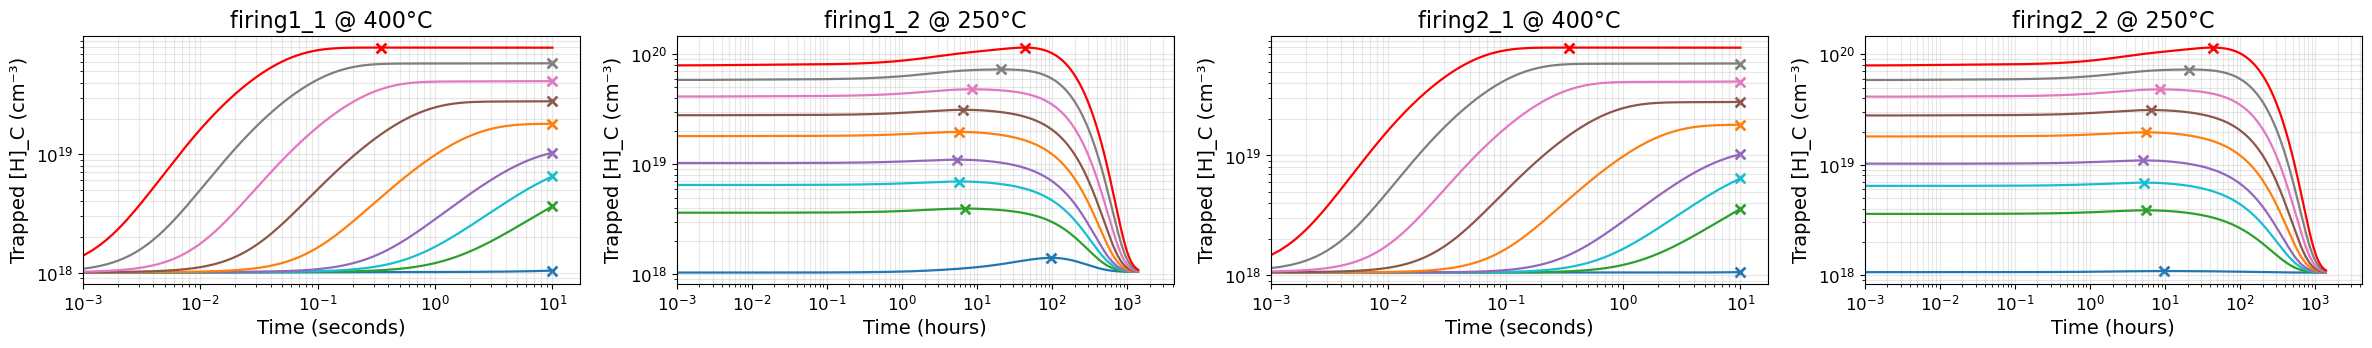

In [24]:
%load_ext autoreload
%autoreload 2

#attempt of cycleability

import matplotlib.pyplot as plt
import sweeps as swp
import simulation_manager as sm
import vizkit as viz
import numpy as np
# import helpers as h

# ---- param sets to sweep ----
good_params = [
    #paper params
   {'A_detrap': 2.5, 'A_trap': 0.9,
     'B_detrap': 1.3,
     'C_detrap': 1.45,
     'D_detrap': 1.2,
     'A_trap_attemptfreq': 1e+13,
     'B_trap_attemptfreq': 1e+13,
     'C_trap_attemptfreq': 1e+13, 
     'D_trap_attemptfreq': 5e+12,
     'A_detrap_attemptfreq': 1e+12,
     'B_detrap_attemptfreq': 1e+12,
     'C_detrap_attemptfreq': 1e+12, 
     'D_detrap_attemptfreq': 1e+12},
#pure cSi deg params
#    {'A_detrap': 2.5, 'A_trap': 0.9,
#     'B_detrap': 0.9,
#     'C_detrap': 1.45,
#     'D_detrap': 1.1,
#     'A_trap_attemptfreq': 1e+13,
#     'B_trap_attemptfreq': 1e+13,
#     'C_trap_attemptfreq': 1e+13, 
#     'D_trap_attemptfreq': 5e+12,
#     'A_detrap_attemptfreq': 1e+12,
#     'B_detrap_attemptfreq': 1e+12,
#     'C_detrap_attemptfreq': 1e+12, 
#     'D_detrap_attemptfreq': 1e+12},
    
]
 

# ---- sweep settings (explicit °C + seconds) ----
anneal_temps_C      = [250]#300,350]
annealing_fire_C    = 670
annealing_fire_s    = 10
annealing_sweep_s   = 3_500_000

firing_temps_C      = [400,500,525,550,600,650, 700, 750,800,]
firing_anneal_C     = 250         
firing_anneal_s     = 5000000
firing2_anneal_C    = 250  
firing2_anneal_s    = 3000000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

# results_dir         = "./sim_data_sweeps"   # change to None if you prefer default; plots aren’t saved
petsc_options       = None
verbose             = False

j = 1
for base_params in good_params:

    schedules = []


    # --- ) Firing sweep: fixed anneal, variable firing
    sched, stage = swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
        n_cycles=2,
    )
    
    schedules+=sched

    # unfired_T=400
    
    # sched, stage = swp.make_unfired_sweep(anneal_temp=250,fire_temp=unfired_T,fire_s=annealing_fire_s,anneal_s=annealing_sweep_s)
    # schedules+=sched
    
    mgr = sm.SimulationManager(base_params=base_params,temp_schedules=schedules, stage_names=["firing1_1","firing1_2","firing2_1","firing2_2"])

    print(schedules)
    # matches = mgr.results_with_stage_temperature(stage="firing", target_T=670)

##
    PANELS = ['anneal_sweep','firing_siox_log','fire_sweep_log','fire2_sweep_log','peak_firingT']#,'exp_overlay']
    PANEL_CTX = [annealing_fire_C, firing_anneal_C, firing_anneal_C, firing2_anneal_C, firing_anneal_C]#, annealing_fire_C]

    viz.plot_multistage_firing_sweep_panels(mgr, annealing_temp_C=firing_anneal_C,ylog=True)

    
    #viz.plot_two_stage_flux_panels(mgr,firing_temp_C=670,annealing_temp_C=250,ylog=True,use_seconds=False,)
    
    #viz.plot_two_stage_deltaA_panels( mgr, firing_temp_C=670, annealing_temp_C=250, ylog=True, )  # set False if you want hours on x for anneal
    #viz.plot_paper(mgr,PANELS,PANEL_CTX,unfired_T=unfired_T)
    
    # viz.plot_full_single_analysis(mgr,PANELS,PANEL_CTX,x_lim_left=1e-2)#'fire_sweep_log','peak_firingT','exp_overlay'],
    #                                #[firing_anneal_C,],#firing2_anneal_C,firing_anneal_C,annealing_fire_C],
    #                                 # )
    
   

    # viz.plot_two_stage_dHdt_panels(mgr,firing_temp_C=650,annealing_temp_C=250,ylog=False,use_seconds=False,)
    j += 1
    


In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sweeps as swp
import simulation_manager as sm
import vizkit as viz

# ---- param sets to sweep (yours) ----
good_params = [
    {'A_detrap': 2.5, 'A_trap': 0.9,
     'B_detrap': 1.3,
     'C_detrap': 1.45,
     'D_detrap': 1.1,
     'A_trap_attemptfreq': 1e+13,
     'B_trap_attemptfreq': 1e+13,
     'C_trap_attemptfreq': 1e+13, 
     'D_trap_attemptfreq': 5e+12,
     'A_detrap_attemptfreq': 1e+12,
     'B_detrap_attemptfreq': 1e+12,
     'C_detrap_attemptfreq': 1e+12, 
     'D_detrap_attemptfreq': 1e+12
}
]

BH_VALUES = [1.3]

# ---- sweep settings (explicit °C + seconds) ----
anneal_temps_C      = [200,225, 250,275, 300, 350]
annealing_fire_C    = 650
annealing_fire_s    = 10
annealing_sweep_s   = 5_000_000

firing_temps_C      = [400,600,650, 700, 750,800,]
firing_anneal_C     = 250         
firing_anneal_s     = 3_000_000
firing2_anneal_C    = 350  
firing2_anneal_s    = 300_000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

# results_dir         = "./sim_data_sweeps"   # change to None if you prefer default; plots aren’t saved
petsc_options       = None
verbose             = True

j = 1
for base_params in good_params:

    schedules = []

    # --- 1) Annealing sweep: fixed firing, variable anneal
    schedules += swp.make_annealing_sweep(
        anneal_temps=anneal_temps_C,
        fire_temp=annealing_fire_C,
        fire_s=annealing_fire_s,
        anneal_s=annealing_sweep_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )

    # --- 2) Firing sweep: fixed anneal, variable firing
    schedules += swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    
    
    schedules += swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing2_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing2_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )

    mgr = sm.SimulationManager(base_params=base_params,temp_schedules=schedules)


    viz.plot_full_single_analysis(mgr,['anneal_sweep','firing_siox_log','fire_sweep_log','fire_sweep_log','peak_firingT','exp_overlay'],[annealing_fire_C,firing_anneal_C,firing_anneal_C,firing2_anneal_C,firing_anneal_C,annealing_fire_C])
    

    j += 1
    

AttributeError: 'list' object has no attribute 'split'

In [ ]:
# --- Bundle writer for run_single_analysis_sharded.py ---

import json
from pathlib import Path
from copy import deepcopy

DEFAULT_CONFIG = {
    # paths / output
    "out_dir": "custom_panels_out",
    "file_format": "png",
    "dpi": 200,

    # temps / durations (match single_analysis defaults you set)
    "anneal_temps_C": [250, 300, 350],
    "anneal_duration_s": 1_000_000,

    "firing_temps_C": [650, 700, 750],
    "firing_anneal_C": 250,
    "firing_anneal_duration_s": 1_000_000,

    "firing2_anneal_C": 350,
    "firing2_anneal_duration_s": 300_000,

    # segments
    "include_room": False,
    "room_C": 27,
    "room_s": 0,

    # pretest behavior inside single_analysis
    "pretest_strict": True,
    "skip_on_pretest_fail": True,
}

DEFAULT_PANELS = ["anneal_linear", "firing_log", "firing2_log", "peak_time_vs_firing"]


def make_tasks_from_good_params(good_params: list[dict]) -> list[dict]:
    """Use good_params as-is: one figure per dict (recommended)."""
    return [dict(p) for p in good_params]


def make_tasks_expanding_BH(good_params: list[dict], bh_values: list[float]) -> list[dict]:
    """
    Optional: expand each good_params entry across B_detrap sweep values.
    Each output task has its own B_detrap overwritten with each bh.
    """
    tasks = []
    for base in good_params:
        for bh in bh_values:
            p = deepcopy(base)
            p["B_detrap"] = float(bh)
            tasks.append(p)
    return tasks


def save_good_params_bundle(
    path: str | Path,
    good_params: list[dict],
    *,
    expand_BH_with: list[float] | None = None,
    config_overrides: dict | None = None,
    panels_override: list[str] | None = None,
):
    """
    Write a JSON file consumable by run_single_analysis_sharded.py.
    - path: output JSON path
    - good_params: list of canonical param dicts (A_detrap, B_detrap, ... , *_attemptfreq)
    - expand_BH_with: if provided, duplicates each task for every B_detrap in this list
    - config_overrides: dict to override DEFAULT_CONFIG entries
    - panels_override: list of panel names (else DEFAULT_PANELS)
    """
    if expand_BH_with:
        tasks = make_tasks_expanding_BH(good_params, expand_BH_with)
    else:
        tasks = make_tasks_from_good_params(good_params)

    cfg = DEFAULT_CONFIG | (config_overrides or {})
    bundle = {
        "tasks": tasks,
        "config": cfg,
        "panels": panels_override or DEFAULT_PANELS,
    }

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as f:
        json.dump(bundle, f, indent=2)
    print(f"[ok] wrote bundle with {len(tasks)} tasks → {path}")
    
BH_VALUES = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
    
save_good_params_bundle(
    "sweep_config_from_good_BH.json",
    good_params,
    expand_BH_with=BH_VALUES,
    config_overrides={
        "out_dir": "custom_panels_out_BH",
        "firing_temps_C": [700, 750, 800, 850],
    },
)


In [2]:
# --- Jupyter reloads ---
%load_ext autoreload
%autoreload 2

# --- Imports (assuming these modules are in your project root / on sys.path) ---
import matplotlib.pyplot as plt
import sweeps as swp
import simulation_manager as sm
import vizkit as viz
import nrel_exp as nrel

# --- Load experiment data (CSV path: adjust to your local path) ---
expt = nrel.load_nrel_anneal_csv("/home/adam/code/diffusion_model/annealing_sweep_NREL.csv")

# --- One base param set (edit as needed) ---
base_params = [
    {'A_detrap': 2.5, 'A_trap': 0.9,
     'B_detrap': 1.3,
     'C_detrap': 1.45,
     'D_detrap': 1.2,
     'A_trap_attemptfreq': 1e+13,
     'B_trap_attemptfreq': 1e+13,
     'C_trap_attemptfreq': 5e+12, 
     'D_trap_attemptfreq': 1e+13,
     'A_detrap_attemptfreq': 1e+12,
     'B_detrap_attemptfreq': 1e+12,
     'C_detrap_attemptfreq': 1e+12, 
     'D_detrap_attemptfreq': 1e+12
},
    {'A_detrap': 2.5, 'A_trap': 0.9,
     'B_detrap': 1.3,
     'C_detrap': 1.45,
     'D_detrap': 1.2,
     'A_trap_attemptfreq': 1e+13,
     'B_trap_attemptfreq': 1e+13,
     'C_trap_attemptfreq': 1e+13, 
     'D_trap_attemptfreq': 1e+13,
     'A_detrap_attemptfreq': 1e+12,
     'B_detrap_attemptfreq': 1e+12,
     'C_detrap_attemptfreq': 1e+12, 
     'D_detrap_attemptfreq': 1e+12
},
    {'A_detrap': 2.5, 'A_trap': 0.9,
     'B_detrap': 1.3,
     'C_detrap': 1.45,
     'D_detrap': 1.2,
     'A_trap_attemptfreq': 1e+12,
     'B_trap_attemptfreq': 1e+12,
     'C_trap_attemptfreq': 1e+12, 
     'D_trap_attemptfreq': 1e+12,
     'A_detrap_attemptfreq': 1e+12,
     'B_detrap_attemptfreq': 1e+12,
     'C_detrap_attemptfreq': 1e+12, 
     'D_detrap_attemptfreq': 1e+12
}
]


# ---- Sweep settings (explicit °C + seconds) ----
anneal_temps_C      = [200,225, 250, 275]
annealing_fire_C    = 650
annealing_fire_s    = 10
annealing_sweep_s   = 5_000_000

firing_temps_C      = [600, 650, 700, 750, 800]
firing_anneal_C     = 250
firing_anneal_s     = 3_000_000
firing2_anneal_C    = 350
firing2_anneal_s    = 300_000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

results_dir         = "./sim_data_sweeps"   # cache dir (created if absent)
petsc_options       = None                  # pass PETSc options if desired
verbose             = False

# --- Build the schedules you want to compare ---
schedules = []
# 1) Annealing sweep: fixed firing, varying anneal temp
schedules += swp.make_annealing_sweep(
    anneal_temps=anneal_temps_C,
    fire_temp=annealing_fire_C,
    fire_s=annealing_fire_s,
    anneal_s=annealing_sweep_s,
    include_room=include_room,
    room_temp=room_temp_C,
    room_s=room_s,
)

# (Optional) 2) Firing sweep: fixed anneal, varying firing temp
# schedules += swp.make_firing_sweep(
#     firing_temps=firing_temps_C,
#     anneal_temp=firing_anneal_C,
#     fire_s=firing_sweep_s,
#     anneal_s=firing_anneal_s,
#     include_room=include_room,
#     room_temp=room_temp_C,
#     room_s=room_s,
# )
for bp in base_params:
    # --- Set up the manager over those schedules ---
    mgr = sm.SimulationManager(
        base_params=bp,
        temp_schedules=schedules,
        results_dir=results_dir,
        petsc_options=petsc_options,
        verbose=verbose,
    )

    # If you want to force-run everything now (requires PETSc):
    # mgr.run_all()  # materializes runs or loads cache; see SimulationManager.ensure() path

    # --- 1) Overlay: experiment vs sim (normalized amplitude; x in hours) ---
    # overlay + numeric tables
    ax, nums, overall = nrel.plot_exp_vs_sim_normalized_overlay_hours(
        mgr,
        firing_temp_C=annealing_fire_C,
        anneal_temps_C=anneal_temps_C,
        layer="C", kind="trapped",
        ylog=False, x_left=1e-5, legend_where="right",
        print_data=False, return_data=True,
        y_clip=(-5, 1.2),
        plot=True# keep the dip visible but readable
    )

    print("Overall shape score:", overall)
    # ax_pk, ax_rt, tnums = nrel.plot_exp_vs_sim_tpeak_treturn(
    #     expt, mgr,
    #     firing_temp_C=annealing_fire_C,
    #     anneal_temps_C=anneal_temps_C,
    #     layer="C", kind="trapped",
    #     return_tol=0.05,
    #     print_data=False, return_data=True,
    # )


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


AttributeError: 'list' object has no attribute 'split'

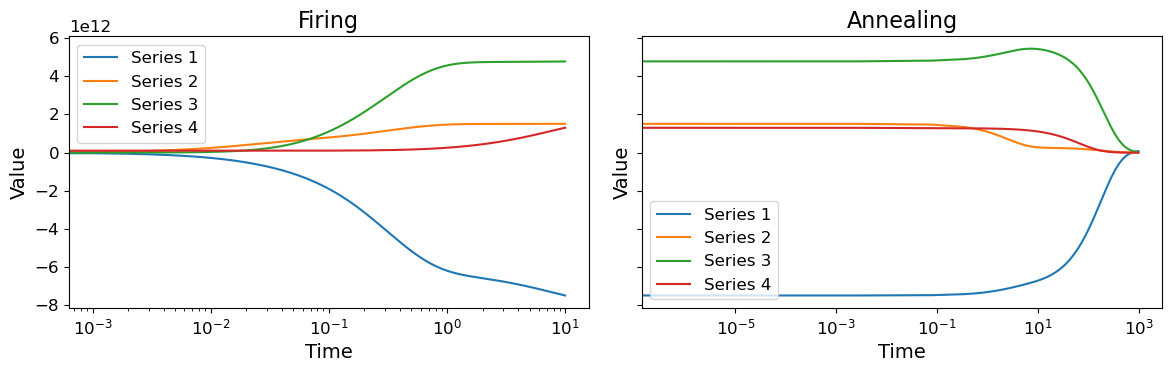

FIRING:
  Series 1: min = -7.490475e+12, max = 0.000000e+00
  Series 2: min = 5.800000e+09, max = 1.510219e+12
  Series 3: min = 3.000000e+07, max = 4.780371e+12
  Series 4: min = 1.000051e+11, max = 1.306932e+12

ANNEALING:
  Series 1: min = -7.491216e+12, max = 7.630593e+10
  Series 2: min = 1.512336e+09, max = 1.510950e+12
  Series 3: min = 2.894985e+10, max = 5.452007e+12
  Series 4: min = 2.788873e+08, max = 1.306937e+12


In [10]:
# Jupyter cell

import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs
fol = "/home/adam/code/diffusion_model/origin_exports"
firing = pd.read_csv(f"{fol}/H_dt_firing.csv")
annealing = pd.read_csv(f"{fol}/H_dt_annealing.csv")

def plot_panel(ax, df, title, n_pairs=4):
    """
    df columns are [t0, y0, t1, y1, ...]
    plots each (t,y) pair as one line on ax and returns list of (label, y_series).
    """
    ys = []
    for k in range(n_pairs):
        t = df.iloc[:, 2*k]
        y = df.iloc[:, 2*k + 1]
        label = f"Series {k+1}"
        ax.plot(t, y, label=label)
        ys.append((label, y))

    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend()
    return ys

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Plot both panels
firing_ys = plot_panel(axes[0], firing, "Firing", n_pairs=4)
anneal_ys = plot_panel(axes[1], annealing, "Annealing", n_pairs=4)

plt.tight_layout()
plt.show()

# Print min/max for each VALUE series (ignore time columns)
def print_minmax(panel_name, ys):
    print(panel_name + ":")
    for label, y in ys:
        # Ensure numeric and ignore NaNs
        y_num = pd.to_numeric(y, errors="coerce")
        print(f"  {label}: min = {y_num.min():.6e}, max = {y_num.max():.6e}")

print_minmax("FIRING", firing_ys)
print()
print_minmax("ANNEALING", anneal_ys)


In [ ]:
%load_ext autoreload
%autoreload 2

# === Sweep for t_peak & t_return, focused on 200–275 °C (with progress) ===
import math, itertools, time
import numpy as np
import pandas as pd
import nrel_exp as nrel, helpers as h, sweeps as swp, simulation_manager as sm

# ------------------ 0) Base params ------------------
base_params = dict(
    A_detrap=2.40, B_detrap=1.20, C_detrap=1.45, D_detrap=1.10, A_trap=0.90,
    A_detrap_attemptfreq=1e12, B_detrap_attemptfreq=1e12,
    C_detrap_attemptfreq=1e12, D_detrap_attemptfreq=1e12,
    A_trap_attemptfreq=1e12, B_trap_attemptfreq=1e12,
    C_trap_attemptfreq=1e12, D_trap_attemptfreq=1e12,
)
def apply_rate_scale(P, scale=1.0):
    P = P.copy()
    for k in list(P.keys()):
        if k.endswith("_attemptfreq"):
            P[k] = float(P[k]) * float(scale)
    return P

# ------------------ 1) Schedules & data ---------------
CSV_PATH = "/home/adam/code/diffusion_model/annealing_sweep_NREL.csv"
expt = nrel.load_nrel_anneal_csv(CSV_PATH)

TARGET_TEMPS = [200, 225, 250, 275]           # focus band
USED_TEMPS = [T for T in TARGET_TEMPS if T in expt]
assert USED_TEMPS, "None of the target temps (200,225,250,275) found in CSV."

FIRE_C, FIRE_S = 650, 10
ANNEAL_S = 2_000_000
RESULTS_DIR = "./sim_data_sweeps"
RETURN_TOL = 0.05

schedules = swp.make_annealing_sweep(
    anneal_temps=USED_TEMPS, fire_temp=FIRE_C, fire_s=FIRE_S,
    anneal_s=ANNEAL_S, include_room=False, room_temp=27, room_s=0
)

# ------------------ 2) Experimental metrics -----------
def exp_metrics(temps):
    rows = []
    for T in temps:
        t_h, j = expt[T]
        tN, yN, y0, ypk, i_pk = h.normalize_baseline_peak(t_h, j, t0_window=(0.1, 0.3))
        rows.append(dict(
            temp_C=T,
            exp_t_peak_hr=float(h.peak_time_hours(tN, i_pk)),
            exp_t_return_hr=float(h.time_to_return_baseline(tN, yN, i_pk, tol=RETURN_TOL)),
        ))
    return pd.DataFrame(rows).set_index("temp_C")

exp_df = exp_metrics(USED_TEMPS)
print("Loaded experimental metrics (focus band):")
print(exp_df, "\n")

# ------------------ 3) Helper: run + metrics -----------
def sim_metrics(params):
    mgr = sm.SimulationManager(params, schedules, results_dir=RESULTS_DIR,
                               petsc_options=None, verbose=False)
    rows = []
    for T in USED_TEMPS:
        t_h, y = nrel._pick_sim_for_anneal_T(mgr, firing_temp_C=FIRE_C,
                                             anneal_temp_C=T, layer="C", kind="trapped")
        if t_h is None:
            rows.append(dict(temp_C=T, t_peak_hr=np.nan, t_return_hr=np.nan))
            continue
        tN, yN, y0, ypk, i_pk = h.normalize_baseline_peak(t_h, y, t0_window=(0.1, 0.3))
        rows.append(dict(
            temp_C=T,
            t_peak_hr=float(h.peak_time_hours(tN, i_pk)),
            t_return_hr=float(h.time_to_return_baseline(tN, yN, i_pk, tol=RETURN_TOL)),
        ))
    return pd.DataFrame(rows).set_index("temp_C")

# ------------------ 4) Objective ----------------------
def score_times_only(sim_df, exp_df, w_peak=1.0, w_ret=1.0):
    s = 0.0
    for T in exp_df.index.intersection(sim_df.index):
        tpk_s, tpk_e = sim_df.at[T,"t_peak_hr"],  exp_df.at[T,"exp_t_peak_hr"]
        trt_s, trt_e = sim_df.at[T,"t_return_hr"],exp_df.at[T,"exp_t_return_hr"]
        def logerr(a,b):
            if not (np.isfinite(a) and np.isfinite(b) and a>0 and b>0): return 2.0
            return (math.log10(a)-math.log10(b))**2
        s += w_peak*logerr(tpk_s, tpk_e) + w_ret*logerr(trt_s, trt_e)
    return float(s)

# ------------------ 5) Candidate grid -----------------
A_detrap_vals = [2.50]
B_detrap_vals = [1.20, 1.25, 1.30]
C_detrap_vals = [1.45, 1.50]
D_detrap_vals = [1.20, 1.25, 1.30]
rate_scales   = [1.0,1.5,2]

grid = list(itertools.product(A_detrap_vals,B_detrap_vals,C_detrap_vals,D_detrap_vals,rate_scales))
print(f"Total candidates: {len(grid)}\n")

# ------------------ 6) Run & print progress ------------
rows = []
t_start = time.time()
for i, (A,B,C,D,s) in enumerate(grid,1):
    P = base_params.copy()
    P.update(dict(A_detrap=A,B_detrap=B,C_detrap=C,D_detrap=D))
    P = apply_rate_scale(P, s)

    print(f"[{i}/{len(grid)}] A={A:.2f} B={B:.2f} C={C:.2f} D={D:.2f} scale={s:.1f} ...", end=" ", flush=True)
    t0 = time.time()
    S = sim_metrics(P)
    elapsed = time.time()-t0
    sc = score_times_only(S, exp_df)
    print(f"✓ {elapsed:.1f}s | score={sc:.3f}", flush=True)

    rows.append({
        "A_detrap":A,"B_detrap":B,"C_detrap":C,"D_detrap":D,"rate_scale":s,
        "score":sc,
        **{f"T{T}_tpk":S.at[T,"t_peak_hr"] if T in S.index else np.nan for T in USED_TEMPS},
        **{f"T{T}_trt":S.at[T,"t_return_hr"] if T in S.index else np.nan for T in USED_TEMPS},
    })
    if i % 8 == 0:
        print(f"--- progress: {i}/{len(grid)} done, elapsed {(time.time()-t_start)/60:.1f} min ---")

df = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)
print(f"\nSweep complete in {(time.time()-t_start)/60:.1f} min.")
print("\nTop 5 results:")
print(df[["score","A_detrap","B_detrap","C_detrap","D_detrap","rate_scale"]].head())

OUT_CSV = "./times_sweep_progress_lowT.csv"
df.to_csv(OUT_CSV, index=False)
print(f"Saved results to {OUT_CSV}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded experimental metrics (focus band):
        exp_t_peak_hr  exp_t_return_hr
temp_C                                
200             186.2            590.2
225              41.7             98.9
250               4.5             10.9
275               1.0              1.5 

Total candidates: 54

[1/54] A=2.50 B=1.20 C=1.45 D=1.20 scale=1.0 ... 

AttributeError: 'list' object has no attribute 'split'

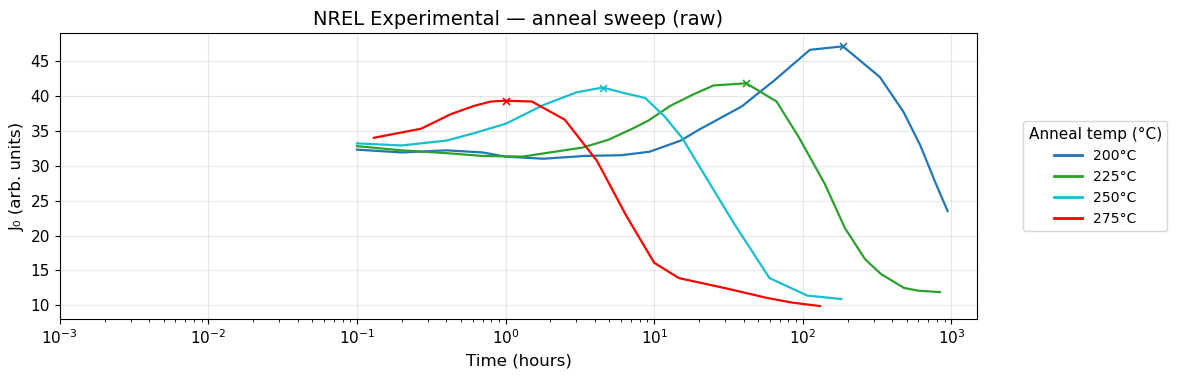


=== Plotting candidate rank 0 — score 0.582 ===
{'A_detrap': np.float64(2.5), 'B_detrap': np.float64(1.3), 'C_detrap': np.float64(1.45), 'D_detrap': np.float64(1.2), 'A_trap': 0.9} rate_scale=2.0

=== Simulation Summary — overlay (layer=C, trapped) ===
RAW (cm^-3):
T(°C)   baseline        peak            Δ            t_peak(hr)
 200  2.778e+19  5.761e+19  2.983e+19   350.60
 225  2.852e+19  4.947e+19  2.095e+19   56.71
 250  3.063e+19  4.233e+19  1.170e+19   10.17
 275  3.310e+19  3.669e+19  3.598e+18   1.87

NORMALIZED (baseline→0, peak→1):
T(°C)   t_peak(hr)   t_return@5%(hr)   min_norm   t_at_min(hr)
 200      350.60           204.96     -0.032         0.00
 225       56.71           142.67     -1.154       555.56
 250       10.17            19.33     -2.614       555.52
 275        1.87             2.33     -9.171       126.06


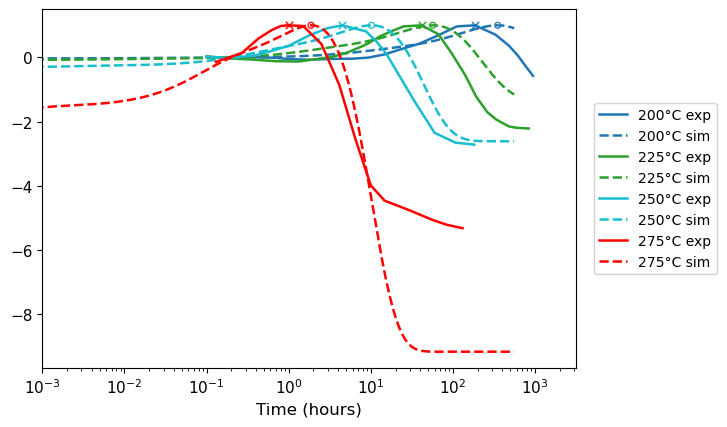


=== SIM t_peak & t_return (layer=C, trapped) ===
T(°C)   t_peak(hr)   t_return(hr) @ 5%   min_norm   t_at_min(hr)
 200      350.60         204.96        -0.032         0.00
 225       56.71         142.67        -1.154       555.56
 250       10.17          19.33        -2.614       555.52
 275        1.87           2.33        -9.171       126.06


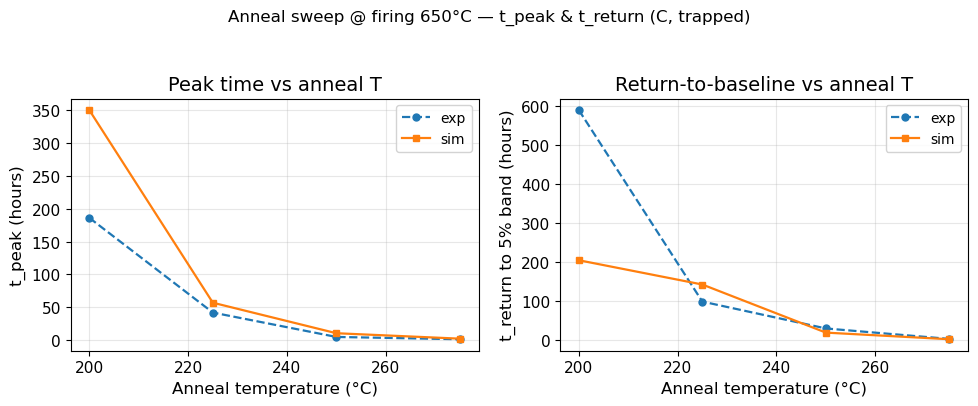


=== Plotting candidate rank 1 — score 0.630 ===
{'A_detrap': np.float64(2.5), 'B_detrap': np.float64(1.25), 'C_detrap': np.float64(1.45), 'D_detrap': np.float64(1.2), 'A_trap': 0.9} rate_scale=2.0

=== Simulation Summary — overlay (layer=C, trapped) ===
RAW (cm^-3):
T(°C)   baseline        peak            Δ            t_peak(hr)
 200  2.797e+19  5.642e+19  2.845e+19   356.06
 225  2.907e+19  4.837e+19  1.931e+19   57.98
 250  3.090e+19  4.126e+19  1.036e+19   10.54
 275  3.170e+19  3.559e+19  3.889e+18   2.00

NORMALIZED (baseline→0, peak→1):
T(°C)   t_peak(hr)   t_return@5%(hr)   min_norm   t_at_min(hr)
 200      356.06           199.49     -0.040         0.00
 225       57.98           132.63     -1.298       555.56
 250       10.54            17.73     -2.979       555.45
 275        2.00             2.45     -8.124       122.99


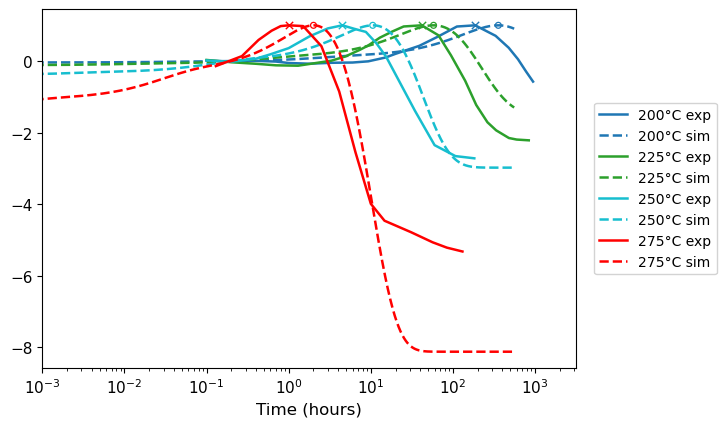


=== SIM t_peak & t_return (layer=C, trapped) ===
T(°C)   t_peak(hr)   t_return(hr) @ 5%   min_norm   t_at_min(hr)
 200      356.06         199.49        -0.040         0.00
 225       57.98         132.63        -1.298       555.56
 250       10.54          17.73        -2.979       555.45
 275        2.00           2.45        -8.124       122.99


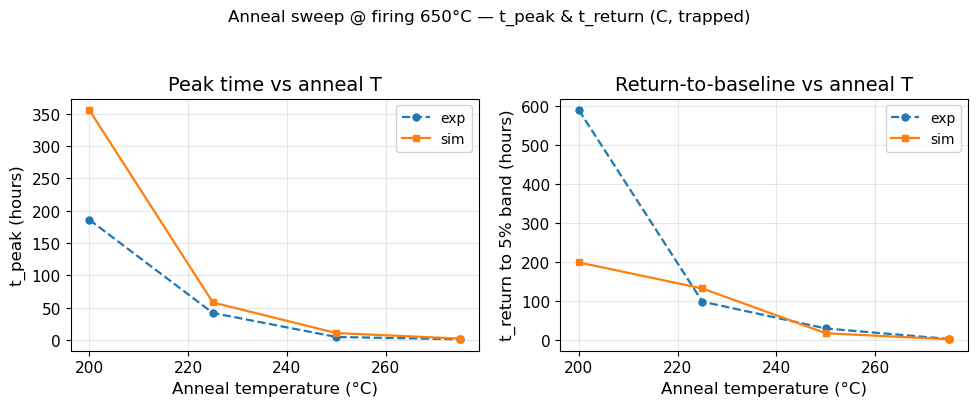


=== Plotting candidate rank 2 — score 0.649 ===
{'A_detrap': np.float64(2.5), 'B_detrap': np.float64(1.2), 'C_detrap': np.float64(1.45), 'D_detrap': np.float64(1.2), 'A_trap': 0.9} rate_scale=2.0

=== Simulation Summary — overlay (layer=C, trapped) ===
RAW (cm^-3):
T(°C)   baseline        peak            Δ            t_peak(hr)
 200  2.827e+19  5.547e+19  2.720e+19   359.90
 225  2.942e+19  4.756e+19  1.813e+19   58.89
 250  3.009e+19  4.052e+19  1.043e+19   10.81
 275  3.058e+19  3.487e+19  4.286e+18   2.09

NORMALIZED (baseline→0, peak→1):
T(°C)   t_peak(hr)   t_return@5%(hr)   min_norm   t_at_min(hr)
 200      359.90           195.65     -0.053         0.00
 225       58.89           126.65     -1.408       555.56
 250       10.81            17.96     -2.878       555.45
 275        2.09             2.62     -7.111       125.16


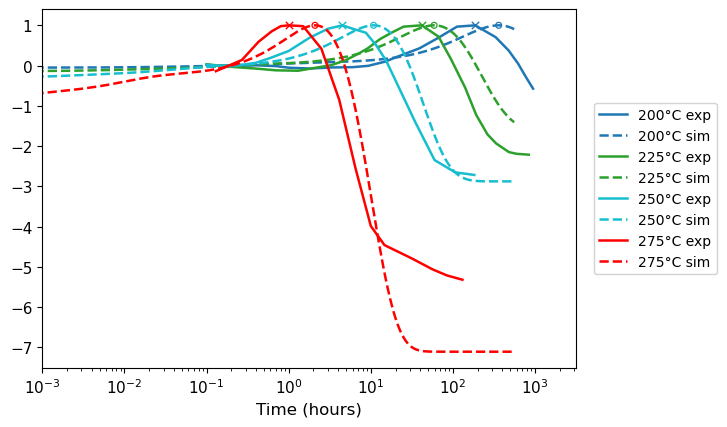


=== SIM t_peak & t_return (layer=C, trapped) ===
T(°C)   t_peak(hr)   t_return(hr) @ 5%   min_norm   t_at_min(hr)
 200      359.90         195.65        -0.053         0.00
 225       58.89         126.65        -1.408       555.56
 250       10.81          17.96        -2.878       555.45
 275        2.09           2.62        -7.111       125.16


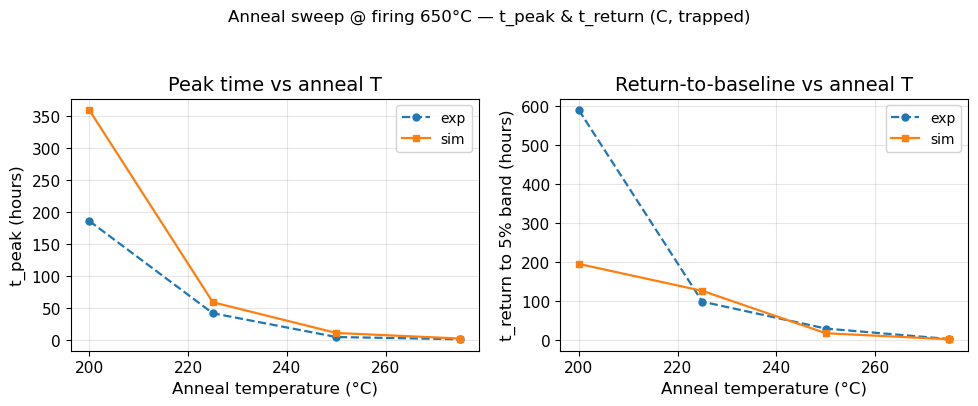

In [ ]:
# === Plot top candidates (overlay + t_peak/t_return), no saving ===
import matplotlib.pyplot as plt
import nrel_exp as nrel
import simulation_manager as sm

TOP_N = 3  # how many best candidates to plot
# 3) Raw experimental J0 (for context)
nrel.plot_expt_anneal_raw({T: expt[T] for T in USED_TEMPS},
                            ylog=False, x_left=1e-3)
plt.show()
for rank, row in df.head(TOP_N).iterrows():
    params = dict(
        A_detrap=row.A_detrap, B_detrap=row.B_detrap,
        C_detrap=row.C_detrap, D_detrap=row.D_detrap,
        A_trap=base_params["A_trap"],
        A_detrap_attemptfreq=1e12*row.rate_scale,
        B_detrap_attemptfreq=1e12*row.rate_scale,
        C_detrap_attemptfreq=1e12*row.rate_scale,
        D_detrap_attemptfreq=1e12*row.rate_scale,
        A_trap_attemptfreq  =1e12*row.rate_scale,
        B_trap_attemptfreq  =1e12*row.rate_scale,
        C_trap_attemptfreq  =1e12*row.rate_scale,
        D_trap_attemptfreq  =1e12*row.rate_scale,
    )

    print(f"\n=== Plotting candidate rank {rank} — score {row.score:.3f} ===")
    print({k: round(v,3) for k,v in params.items() if not k.endswith('freq')},
          f"rate_scale={row.rate_scale}")

    mgr = sm.SimulationManager(params, schedules, results_dir=RESULTS_DIR,
                               petsc_options=None, verbose=False)

    # 1) Overlay plot (normalized amplitude)
    nrel.plot_exp_vs_sim_normalized_overlay_hours(
        expt, mgr,
        firing_temp_C=FIRE_C,
        anneal_temps_C=USED_TEMPS,
        layer="C", kind="trapped",
        ylog=False, x_left=1e-3, legend_where="right",
        print_data=True,
    )
    plt.show()

    # 2) Timing comparison plot (t_peak & t_return)
    nrel.plot_exp_vs_sim_tpeak_treturn(
        expt, mgr,
        firing_temp_C=FIRE_C,
        anneal_temps_C=USED_TEMPS,
        layer="C", kind="trapped",
        return_tol=RETURN_TOL,
        print_data=True,
    )
    plt.show()

    


In [1]:
# %% [markdown]
# Top-N replay notebook cell: load best params from CSV, build schedules, run analyses

# %% setup
%load_ext autoreload
%autoreload 2

import math
import pandas as pd
import matplotlib.pyplot as plt

import sweeps as swp
import simulation_manager as sm
import vizkit as viz
import helpers as h  # for building params if you need it later

# ---------- CONFIG ----------
CSV_PATH      = "/home/adam/code/diffusion_model/all_scores.csv"  # <-- output of combine_analysis.py
TOP_N         = 2                                            # <-- change to any N
worst_score    = 100
VERBOSE       = False
RESULTS_DIR   = None            # or e.g. "/home/agoga/sandbox/diffusion/sim_data"
PETSC_OPTIONS = None

# sweep settings (your values)
anneal_temps_C      = [200,225, 250,275]
annealing_fire_C    = 650
annealing_fire_s    = 10
annealing_sweep_s   = 5_000_000

firing_temps_C      = [650, 700, 750, 800]
firing_anneal_C     = 250
firing_anneal_s     = 3_000_000
firing2_anneal_C    = 350
firing2_anneal_s    = 300_000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

# Which viz panels & context temps (kept from your example)
PANELS = ['anneal_sweep','firing_siox_log','fire_sweep_log','fire_sweep_log','peak_firingT','exp_overlay']
PANEL_CTX = [annealing_fire_C, firing_anneal_C, firing_anneal_C, firing2_anneal_C, firing_anneal_C, annealing_fire_C]

# ---------- load + select "best per unique value of each swept parameter" ----------
df = pd.read_csv(CSV_PATH)

# Base filter: passing + finite (and optional worst_score threshold)
df_base = df[(df["pretest"].str.upper() == "OK") &
             df["overall"].apply(lambda x: math.isfinite(float(x)))]
if worst_score is not None:
    try:
        df_base = df_base[df_base["overall"] < float(worst_score)]
    except Exception:
        pass

# All parameter columns
param_cols = [c for c in df_base.columns if c.startswith("param_")]

# Consider only parameters that were actually swept (more than one unique value)
swept_param_cols = [c for c in param_cols if df_base[c].nunique(dropna=False) > 1]

# For each swept parameter and each of its unique values, pick the row with MIN overall
best_rows = []
for pcol in swept_param_cols:
    for val in sorted(df_base[pcol].dropna().unique()):
        sub = df_base[df_base[pcol] == val]
        if sub.empty:
            continue
        best_rows.append(sub.loc[sub["overall"].idxmin()])

# Deduplicate by the full parameter vector (so the same param set isn’t plotted twice)
def param_tuple(row):
    return tuple((c, row[c]) for c in sorted(param_cols))

unique_best_map = {}
for row in best_rows:
    key = param_tuple(row)
    score = float(row["overall"])
    if (key not in unique_best_map) or (score < float(unique_best_map[key]["overall"])):
        unique_best_map[key] = row

# Optionally cap how many total we’ll plot (keep the globally best TOP_N if you want)
unique_best = list(unique_best_map.values())
unique_best = sorted(unique_best, key=lambda r: float(r["overall"]))
if TOP_N is not None:
    unique_best = unique_best[:TOP_N]

# Convert rows → dicts of params (strip "param_" prefix)
def row_to_param_dict(row):
    return {c[len("param_"):]: row[c] for c in param_cols}

good_params = [row_to_param_dict(r) for r in unique_best]

if VERBOSE:
    print(f"Swept parameters considered: {swept_param_cols}")
    print(f"Selected {len(good_params)} unique best parameter sets")
    preview_cols = ["overall"] + sorted(param_cols)
    display(pd.DataFrame(unique_best)[preview_cols].head(10))


# ---------- build schedules once (same as your notebook pattern) ----------
def build_schedules():
    schedules = []
    # 1) Annealing sweep (fixed firing)
    schedules += swp.make_annealing_sweep(
        anneal_temps=anneal_temps_C,
        fire_temp=annealing_fire_C,
        fire_s=annealing_fire_s,
        anneal_s=annealing_sweep_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    # 2) Firing sweep @ firing_anneal_C
    schedules += swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    # 3) Firing sweep @ firing2_anneal_C
    schedules += swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing2_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing2_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    return schedules
# ---------- load + select TOP_N per unique value of each swept parameter ----------
df = pd.read_csv(CSV_PATH)

# Base filter: passing + finite (and optional worst_score threshold)
df_base = df[(df["pretest"].str.upper() == "OK") &
             df["overall"].apply(lambda x: math.isfinite(float(x)))]
if worst_score is not None:
    try:
        df_base = df_base[df_base["overall"] < float(worst_score)]
    except Exception:
        pass

# All parameter columns
param_cols = [c for c in df_base.columns if c.startswith("param_")]

# Parameters that were actually swept (more than one unique value)
swept_param_cols = [c for c in param_cols if df_base[c].nunique(dropna=False) > 1]

def row_to_param_dict(row):
    return {c[len("param_"):]: row[c] for c in param_cols}

# ---------- build schedules once ----------
schedules = build_schedules()

# ---------- run analyses: TOP_N per unique value for each swept parameter ----------
for pcol in swept_param_cols:
    pname = pcol[len("param_"):]
    unique_vals = sorted(df_base[pcol].dropna().unique())

    for val in unique_vals:
        sub = df_base[df_base[pcol] == val]
        if sub.empty:
            continue

        picked = sub.nsmallest(TOP_N, "overall")

        print(f"\n=== Parameter: {pname} = {val} → best {len(picked)} (TOP_N={TOP_N}) ===")
        for rank, (rid, row) in enumerate(picked.iterrows(), start=1):
            base_params = row_to_param_dict(row)
            overall = float(row["overall"])
            print(f"  [{rank}/{TOP_N}] overall={overall:.6g}")

            mgr = sm.SimulationManager(
                base_params=base_params,
                temp_schedules=schedules,
                results_dir=RESULTS_DIR,
                petsc_options=PETSC_OPTIONS,
                verbose=VERBOSE,
            )

            viz.plot_full_single_analysis(
                mgr,
                PANELS,
                PANEL_CTX,
                show_params_in_title=True
            )




=== Parameter: A_detrap = 2.35 → best 2 (TOP_N=2) ===
  [1/2] overall=0.206699


AttributeError: 'list' object has no attribute 'split'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Will render 1974 selections spanning 0.13 → 10 (step 0.005)

[1/1974] target≈0.13  actual=0.13  row=0  params={'A_detrap': np.float64(2.5), 'B_detrap': np.float64(0.8), 'C_detrap': np.float64(1.5), 'D_detrap': np.float64(1.1), 'A_trap': np.float64(0.9), 'A_trap_attemptfreq': np.float64(10000000000000.0), 'B_trap_attemptfreq': np.float64(1000000000000.0), 'C_trap_attemptfreq': np.float64(5000000000000.0), 'D_trap_attemptfreq': np.float64(10000000000000.0)}
score new:0.14441134939050576


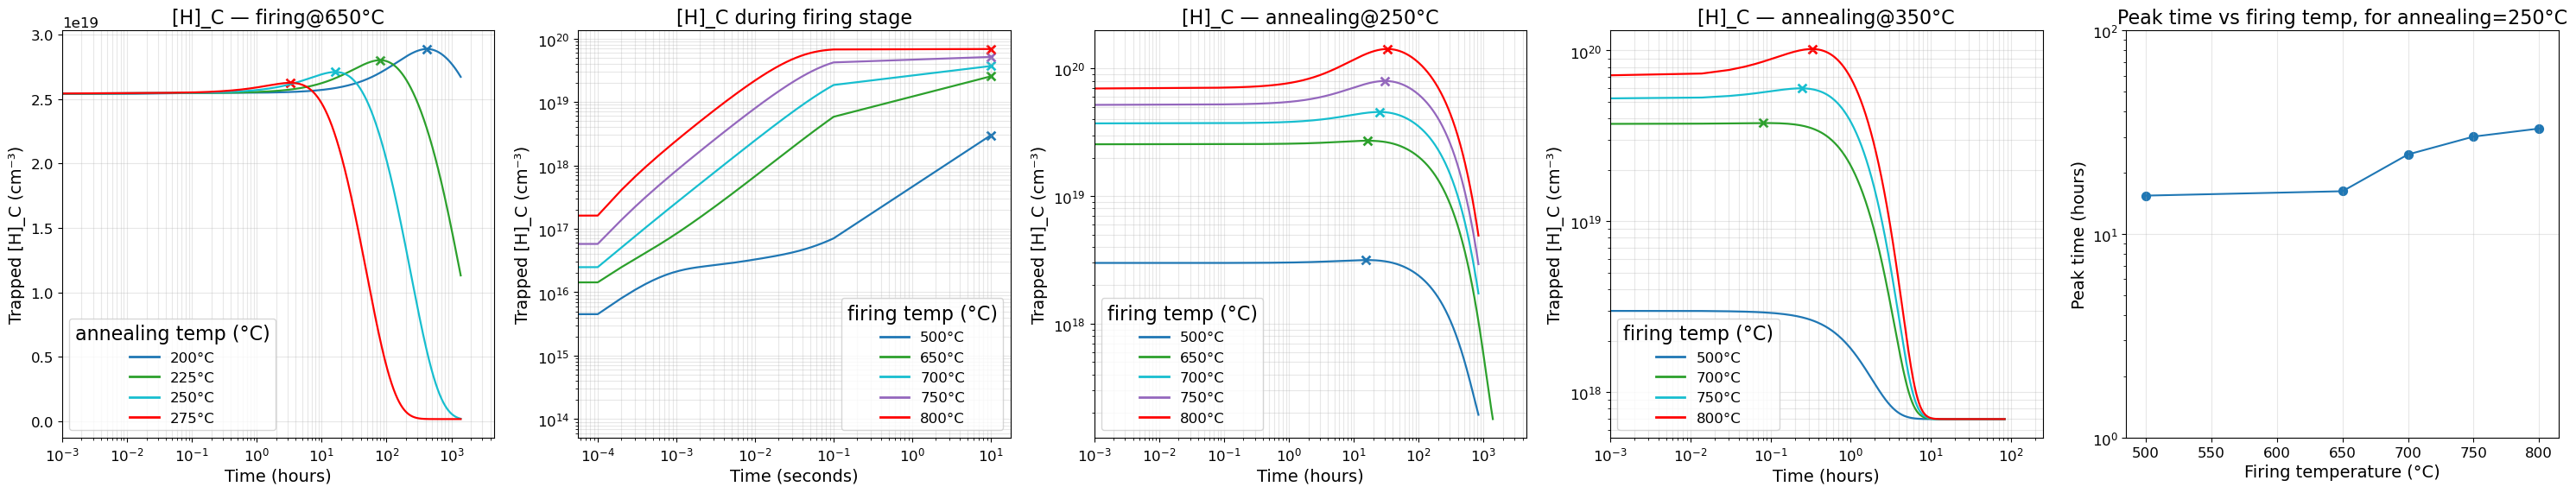

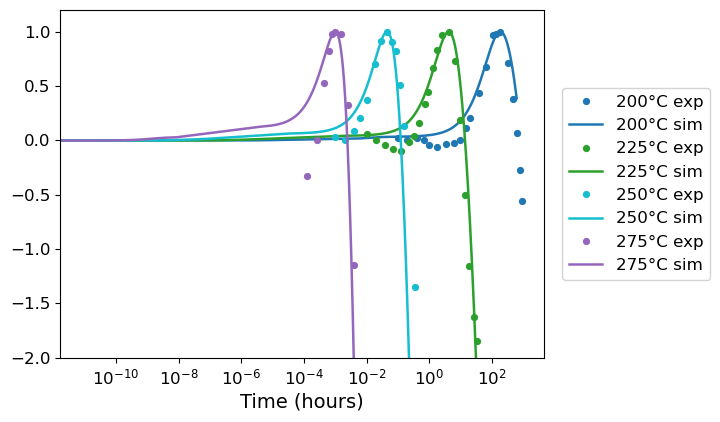


[2/1974] target≈0.135  actual=0.1349  row=37  params={'A_detrap': np.float64(2.5), 'B_detrap': np.float64(0.9), 'C_detrap': np.float64(1.55), 'D_detrap': np.float64(1.1), 'A_trap': np.float64(0.9), 'A_trap_attemptfreq': np.float64(10000000000000.0), 'B_trap_attemptfreq': np.float64(1000000000000.0), 'C_trap_attemptfreq': np.float64(10000000000000.0), 'D_trap_attemptfreq': np.float64(10000000000000.0)}
score new:0.16552519984548125


KeyboardInterrupt: 

In [ ]:
# %% [markdown]
# every few scores we show

# %% setup
%load_ext autoreload
%autoreload 2

import math
import pandas as pd
import matplotlib.pyplot as plt

import sweeps as swp
import simulation_manager as sm
import vizkit as viz
import helpers as h  # for building params if you need it later
# ---------- build schedules once (same as your notebook pattern) ----------
def build_schedules():
    schedules = []
    # 1) Annealing sweep (fixed firing)
    schedules += swp.make_annealing_sweep(
        anneal_temps=anneal_temps_C,
        fire_temp=annealing_fire_C,
        fire_s=annealing_fire_s,
        anneal_s=annealing_sweep_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    # 2) Firing sweep @ firing_anneal_C
    schedules += swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    # 3) Firing sweep @ firing2_anneal_C
    schedules += swp.make_firing_sweep(
        firing_temps=firing_temps_C,
        anneal_temp=firing2_anneal_C,
        fire_s=firing_sweep_s,
        anneal_s=firing2_anneal_s,
        include_room=include_room,
        room_temp=room_temp_C,
        room_s=room_s,
    )
    return schedules
# ---------- CONFIG ----------
CSV_PATH      = "/home/adam/code/diffusion_model/all_scores.csv"  # <-- output of combine_analysis.py
TOP_N         = 2                                                # <-- change to any N
worst_score    = 10
VERBOSE       = False
RESULTS_DIR   = None            # or e.g. "/home/agoga/sandbox/diffusion/sim_data"
PETSC_OPTIONS = None

# sweep settings (your values)
anneal_temps_C      = [200,225, 250,275]
annealing_fire_C    = 650
annealing_fire_s    = 10
annealing_sweep_s   = 5_000_000

firing_temps_C      = [500, 700, 750, 800]
firing_anneal_C     = 250
firing_anneal_s     = 3_000_000
firing2_anneal_C    = 350
firing2_anneal_s    = 300_000
firing_sweep_s      = 10

include_room        = False
room_temp_C         = 27
room_s              = 100_000

# Which viz panels & context temps (kept from your example)
PANELS = ['anneal_sweep','firing_siox_log','fire_sweep_log','fire_sweep_log','peak_firingT','exp_overlay']
PANEL_CTX = [annealing_fire_C, firing_anneal_C, firing_anneal_C, firing2_anneal_C, firing_anneal_C, annealing_fire_C]


# ---------- load & prepare candidates over a score range ----------
SCORE_STEP    = 0.005           # or 0.10
DEDUPLICATE   = True           # avoid repeating the same row across targets

df = pd.read_csv(CSV_PATH)
df["overall"] = pd.to_numeric(df["overall"], errors="coerce")
df["pretest"] = df["pretest"].astype(str)

# Keep only passing + finite + under worst_score
df_ok = df[
    (df["pretest"].str.upper() == "OK")
    & df["overall"].apply(lambda x: math.isfinite(float(x)))
    & (df["overall"].astype(float) <= float(worst_score))
    & (df["overall"].astype(float) != float(0))
].copy()

if df_ok.empty:
    raise ValueError("No rows pass pretest/finite and <= worst_score.")

# Ensure numeric, sort ascending (best first)
df_ok["overall"] = df_ok["overall"].astype(float)
df_ok = df_ok.sort_values("overall", ascending=True).reset_index(drop=True)

min_score = float(df_ok["overall"].min())
max_score = float(df_ok["overall"].max())
if min_score > worst_score:
    raise ValueError(f"min overall ({min_score:.4g}) exceeds worst_score ({worst_score:.4g}).")

# Build target scores from best → worst_score in steps
import numpy as np
targets = list(np.arange(min_score, worst_score + 1e-12, SCORE_STEP))

# Helper to turn a row into param dict (strip "param_" prefix)
param_cols = [c for c in df_ok.columns if c.startswith("param_")]
def row_to_param_dict(row):
    return {c[len("param_"):]: row[c] for c in param_cols}

# Pick closest rows for each target (optionally de-duplicated)
picked = []
seen_indices = set()
for t in targets:
    # distance to target
    distances = (df_ok["overall"] - t).abs()
    # sorted candidate indices by closeness
    ordered = distances.sort_values().index.tolist()
    chosen_idx = None
    if DEDUPLICATE:
        for idx in ordered:
            if idx not in seen_indices:
                chosen_idx = idx
                break
    else:
        chosen_idx = ordered[0]

    if chosen_idx is None:
        # all candidates exhausted (should be rare unless very few rows)
        continue

    seen_indices.add(chosen_idx)
    row = df_ok.loc[chosen_idx]
    picked.append({
        "target_score": float(t),
        "actual_score": float(row["overall"]),
        "params": row_to_param_dict(row),
        "row_index": int(chosen_idx),
    })

if not picked:
    raise ValueError("No candidates were picked for the target range.")

# ---------- run analyses for each picked parameter set ----------
print(f"Will render {len(picked)} selections spanning {min_score:.4g} → {worst_score:.4g} (step {SCORE_STEP})")
schedules = build_schedules()

for j, sel in enumerate(picked, start=1):
    base_params = sel["params"]
    targ = sel["target_score"]
    actual = sel["actual_score"]
    print(f"\n[{j}/{len(picked)}] target≈{targ:.4g}  actual={actual:.4g}  row={sel['row_index']}  params={base_params}")

    mgr = sm.SimulationManager(
        base_params=base_params,
        temp_schedules=schedules,
        results_dir=RESULTS_DIR,
        petsc_options=PETSC_OPTIONS,
        verbose=VERBOSE,
    )

    viz.plot_full_single_analysis(
        mgr,
        PANELS,
        PANEL_CTX
    )


In [1]:
# ============================
# Diagnose flux scales in the actual simulation
# ============================
%load_ext autoreload
%autoreload 2

import numpy as np
import helpers as h
import simulation_manager as sm
from fourstates import SAMPLE_LENGTH, SCALE_A, SCALE_B, SCALE_C, SCALE_D

print("Running rhs_from_state test...")

# --- Build ONE simulation just to get a SimulationResult ---
test_params = {
    'A_detrap': 2.5, 'A_trap': 0.9,
    'B_detrap': 1.3,
    'C_detrap': 1.45,
    'D_detrap': 1.2,
    'A_trap_attemptfreq': 1e13,
    'B_trap_attemptfreq': 1e13,
    'C_trap_attemptfreq': 1e13,
    'D_trap_attemptfreq': 5e12,
    'A_detrap_attemptfreq': 1e12,
    'B_detrap_attemptfreq': 1e12,
    'C_detrap_attemptfreq': 1e12,
    'D_detrap_attemptfreq': 1e12
}

schedule = "10:950C, 3600:350C"
mgr_test = sm.SimulationManager(
    base_params=test_params,
    temp_schedules=[schedule],
    stage_names=["firing", "annealing"],
    verbose=False
)

# ---- pick a simulation just like in your plotting cell ----
# (reuse your mgr from above; if you're in a fresh notebook, rebuild mgr first)
firing_T    = 670
annealing_T = 250

tol = getattr(mgr, "_tol", 0.1)

fire_matches = mgr.results_with_stage_temperature(stage="firing", target_T=firing_T)
matches = []
for r in fire_matches:
    try:
        if abs(r.temperature_for_stage("annealing") - annealing_T) <= tol:
            matches.append(r)
    except KeyError:
        pass

if not matches:
    raise RuntimeError("No run found with those firing/annealing temperatures.")

res = matches[0]
print("Using simulation:", res.signature)
print("Schedule:", res.schedule_spec)
print("Stages:", res.stage_names(), res.stage_bounds())


# ---- helper: summarize one flux array ----
def summarize_flux_array(F, label, dx=None):
    """
    F: shape (N, 4) raw fluxes from res.fluxes (model units, per volume)
    dx: optional list of thicknesses (cm) to convert to cm^-2 s^-1
    """
    F = np.asarray(F, float)
    names = ["A→B", "B→C", "C→D", "D→E"]

    if dx is not None:
        dx = np.asarray(dx, float)
        F_area = F * dx  # broadcast: each column * its interface thickness
        unit = "cm^-2 s^-1  (per area)"
    else:
        F_area = F
        unit = "model units  (per volume)"

    print(f"\n=== {label} ({unit}) ===")
    for j, nm in enumerate(names):
        fj = F_area[:, j]
        absfj = np.abs(fj)
        finite = np.isfinite(absfj)
        if not finite.any():
            print(f"  {nm}: all NaN/inf")
            continue
        absfj = absfj[finite]
        stats = {
            "min":  absfj.min(),
            "p5":   np.percentile(absfj, 5),
            "med":  np.percentile(absfj, 50),
            "p95":  np.percentile(absfj, 95),
            "max":  absfj.max(),
        }
        print(f"  {nm}: "
              f"min={stats['min']:.3e}, "
              f"p5={stats['p5']:.3e}, "
              f"med={stats['med']:.3e}, "
              f"p95={stats['p95']:.3e}, "
              f"max={stats['max']:.3e}")


# ---- layer/interface thicknesses (cm) ----
dxA = (SCALE_A * SAMPLE_LENGTH) * 1e-7
dxB = (SCALE_B * SAMPLE_LENGTH) * 1e-7
dxC = (SCALE_C * SAMPLE_LENGTH) * 1e-7
dxD = (SCALE_D * SAMPLE_LENGTH) * 1e-7
dx_interfaces = [dxA, dxB, dxC, dxD]


# ---- 1) Whole run ----
t_all, F_all = res.fluxes(stage=None)
summarize_flux_array(F_all, label="Whole trajectory (raw per-volume)")
summarize_flux_array(F_all, label="Whole trajectory (per area)", dx=dx_interfaces)

# ---- 2) Firing stage only ----
if res.has_stage("firing"):
    t_fir, F_fir = res.fluxes(stage="firing")
    summarize_flux_array(F_fir, label="Firing stage (raw per-volume)")
    summarize_flux_array(F_fir, label="Firing stage (per area)", dx=dx_interfaces)
else:
    print("\n(no 'firing' stage in this run)")

# ---- 3) Annealing stage only ----
if res.has_stage("annealing"):
    t_ann, F_ann = res.fluxes(stage="annealing")
    summarize_flux_array(F_ann, label="Annealing stage (raw per-volume)")
    summarize_flux_array(F_ann, label="Annealing stage (per area)", dx=dx_interfaces)
else:
    print("\n(no 'annealing' stage in this run)")


Running rhs_from_state test...


KeyboardInterrupt: 